# Import

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import torch
import numpy as np

In [3]:
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torchvision import transforms


In [4]:
import albumentations as albu
from PIL import Image

In [5]:
from torch.utils.data import Dataset
from typing import Union,List,Tuple
import pathlib
from timeit import default_timer as timer
from torch.utils.data import DataLoader
import h5py
from tqdm import tqdm
import torchvision
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import time
from torch.utils.tensorboard import SummaryWriter

In [6]:
# mlfmow library
import mlflow
import mlflow.pytorch
import shutil
from mlflow.exceptions import MlflowException
import datetime

# Hyperparameters

In [7]:
# Parameters
batch_size = 32
period_size = 8
weight_decay = 0.1
epsilon = 10**(-8)
epochs_num = 3
learning_rate = 10**(-3)
n_channel = 1
class_num = 3
air_threshold = 0.85
step = 1
filename_prefix = "os_long"
stride = 32
train_size = 0.7
output = 128
dropout_rate = 0.5
start_index = 30
end_index = 50

# MLflow run

In [8]:
import mlflow
from mlflow.exceptions import MlflowException
import datetime
import torch
from torch.utils.tensorboard import SummaryWriter

# End any active MLflow run
mlflow.end_run()



# Create a string with hyperparameters for the experiment name
hyperparams_str = (f"bs{batch_size}_ps{period_size}_dr{dropout_rate}_ep{epochs_num}_"
                   f"lr{learning_rate}_nc{n_channel}_at{air_threshold}_str{stride}_"
                   f"ts{train_size}_out{output}_step{step}")

# Put the device on GPU if possible to train the model faster than with CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Function to generate a unique experiment name
def generate_experiment_name():
    return f"experiment-{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"

# Generate a unique experiment name
experiment_name = generate_experiment_name()

# Create and set a new experiment
try:
    experiment_id = mlflow.create_experiment(experiment_name)
    mlflow.set_experiment(experiment_name)
except MlflowException as e:
    print(f"Error creating experiment: {e}")

# Verify the experiment is set correctly
print(f"Set experiment '{experiment_name}'")

# TensorBoard logs directory
tensorboard_logs_dir = f"D:/Donnees_pour_segmentation_RDN/data/runs/tensorboard_logs/{experiment_name}_{hyperparams_str}"

# Start an MLflow run
mlflow.start_run(run_name=f"training_adapted-{hyperparams_str}_{datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Define the directories using f-strings
label_dir = f"D:/Donnees_pour_segmentation_RDN/data/{filename_prefix}/Label"
input_dir = f"D:/Donnees_pour_segmentation_RDN/data/{filename_prefix}/Unseg"
new_label_dir = f"D:/Donnees_pour_segmentation_RDN/data/{filename_prefix}_mini/Label"
new_input_dir = f"D:/Donnees_pour_segmentation_RDN/data/{filename_prefix}_mini/Unseg"

# Now you can use these directories in your functions
print(label_dir)
print(input_dir)
print(new_label_dir)
print(new_input_dir)

# Log parameters
mlflow.log_param("device", "cuda:0" if torch.cuda.is_available() else "cpu")
mlflow.log_param("batch_size", batch_size)
mlflow.log_param("period_size", period_size)
mlflow.log_param("weight_decay", weight_decay)
mlflow.log_param("epsilon", epsilon)
mlflow.log_param("epochs_num", epochs_num)
mlflow.log_param("learning_rate", learning_rate)
mlflow.log_param("n_channel", n_channel)
mlflow.log_param("class_num", class_num)
mlflow.log_param("label_dir", label_dir)
mlflow.log_param("input_dir", input_dir)
mlflow.log_param("stride", stride)
mlflow.log_param("train_size", train_size)
mlflow.log_param("output", output)

# Initialize TensorBoard writer
writer = SummaryWriter(tensorboard_logs_dir)


Set experiment 'experiment-2024-08-12_14-26-13'
D:/Donnees_pour_segmentation_RDN/data/os_long/Label
D:/Donnees_pour_segmentation_RDN/data/os_long/Unseg
D:/Donnees_pour_segmentation_RDN/data/os_long_mini/Label
D:/Donnees_pour_segmentation_RDN/data/os_long_mini/Unseg


# Select files

In [9]:
# Ensure the new directories exist
os.makedirs(new_label_dir, exist_ok=True)
os.makedirs(new_input_dir, exist_ok=True)

# Function to empty the destination directories
def empty_directory(directory):
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        if os.path.isfile(file_path) or os.path.islink(file_path):
            os.unlink(file_path)
        elif os.path.isdir(file_path):
            shutil.rmtree(file_path)

# Function to copy files
def copy_files(file_paths, destination_dir):
    for file_path in file_paths:
        shutil.copy(file_path, destination_dir)

# Function to get the number of digits in the file names
def get_num_digits(directory):
    files = [f for f in os.listdir(directory) if f.endswith('.tif')]
    if not files:
        raise ValueError("No .tif files found in the directory")
    num_digits = len(files[0].split('_')[-1].split('.')[0])
    return num_digits

# Function to get image files by index range
def get_image_files_by_index(directory, start_index, end_index):
    num_digits = get_num_digits(directory)
    image_files = []
    for idx in range(start_index, end_index + 1):
        file_name = f"{directory}/{filename_prefix}_{idx:0{num_digits}}.tif"
        if os.path.exists(file_name):
            image_files.append(file_name)
        else:
            print(f"File not found: {file_name}")
    return image_files

# Empty the destination directories
empty_directory(new_label_dir)
empty_directory(new_input_dir)


# Get the list of image files
label_files = get_image_files_by_index(label_dir, start_index, end_index)
input_files = get_image_files_by_index(input_dir, start_index, end_index)

# Copy the files to the new directories
copy_files(label_files, new_label_dir)
copy_files(input_files, new_input_dir)

print("Files copied successfully!")

# Validate copied files
def validate_files(directory):
    files = os.listdir(directory)
    if not files:
        print(f"No files found in {directory}")
    else:
        print(f"Found {len(files)} files in {directory}")

validate_files(new_label_dir)
validate_files(new_input_dir)

Files copied successfully!
Found 21 files in D:/Donnees_pour_segmentation_RDN/data/os_long_mini/Label
Found 21 files in D:/Donnees_pour_segmentation_RDN/data/os_long_mini/Unseg


# Dataset

In [10]:
class HDF52D(Dataset):
    def __init__(self, patches, input_list, label_list, transform=None, mode='train', n_channels=1, step=1):
        self.patches = patches
        self.input_list = input_list
        self.label_list = label_list
        self.transform = transform
        self.mode = mode
        self.n_channels = n_channels
        self.step = step

    def __getitem__(self, idx):
        p = self.patches[idx]
        filename, top, left, height, width = p
        top, left, height, width = map(int, [top, left, height, width])
        image = self.input_list[filename][top:top + height, left:left + width]
        mask = self.label_list[filename][top:top + height, left:left + width]
        
        image_index = int(filename.split('_')[-1].split('.')[0])
        
        if self.n_channels > 1:
            # Load a 2.5D image stack
            full_image = load_2_5D_image(image_index, new_input_dir, self.n_channels, self.step)
            image = full_image[:, top:top + height, left:left + width]
        else:
            # Handle single-channel case
            image = np.expand_dims(image, axis=0)  # Convert to (1, H, W)

        sample = {'image': image, 'mask': mask}

        if self.transform is not None:
            sample = self.transform(sample)
        
        return sample

    def __len__(self):
        return len(self.patches)

    def set_mode(self, mode):
        self.mode = mode
    
    def set_n_channels(self, n_channels):
        self.n_channels = n_channels

    def set_step(self, step):
        self.step = step



# Update functions to set n_channels and step
def set_n_channels(dataset, n_channels):
    if isinstance(dataset, HDF52D):
        dataset.set_n_channels(n_channels)
    else:
        raise TypeError("The dataset must be an instance of the HDF52D class.")

def set_step(dataset, step):
    if isinstance(dataset, HDF52D):
        dataset.set_step(step)
    else:
        raise TypeError("The dataset must be an instance of the HDF52D class.")

def set_dataset_mode(dataset, mode):
    if isinstance(dataset, HDF52D):
        dataset.set_mode(mode)
    else:
        raise TypeError("The dataset must be an instance of the HDF52D class.")

def load_patches(patches):
    if isinstance(patches, pd.DataFrame):
        patches_list = patches.values.tolist()
    else:
        patches_list = patches
    return patches_list


# Dataprocess

In [11]:
def get_neighbor_paths(image_index, directory, n_channels=n_channel, step=1):
    neighbors = []
    
    # Calculate neighbor indices
    for i in range(-(n_channels // 2), (n_channels // 2) + 1):
        neighbor_index = image_index + i * step
        
        # Handle borders by repeating the border image
        if neighbor_index < start_index:
            neighbor_index = start_index
        elif neighbor_index > end_index:
            neighbor_index = end_index
        
        neighbors.append(neighbor_index)
    
    # Generate the neighbor paths
    neighbor_paths = [os.path.join(directory, f"{filename_prefix}_{n:04d}.tif").replace("\\", "/") for n in neighbors]
    
    return neighbor_paths




def load_2_5D_image(image_index, directory, n_channels=1, step=1):
    if n_channels == 1:
        # Load the single image directly
        image_path = os.path.join(directory, f"{filename_prefix}_{image_index:04d}.tif").replace("\\", "/")
        image = Image.open(image_path).convert('L')
        return np.expand_dims(np.array(image), axis=0)  # Return (1, H, W) image

    else:
        # Original logic for multi-channel (2.5D) images
        neighbor_paths = get_neighbor_paths(image_index, directory, n_channels, step)
        images = [Image.open(p).convert('L') for p in neighbor_paths if p is not None]
        image_stack = np.stack([np.array(img) for img in images], axis=0)  # Stack along the first dimension (C, H, W)
        return image_stack











def create_one_hot(mask, num_classes=3):
    one_hot_mask = torch.zeros([mask.shape[0], num_classes, mask.shape[1], mask.shape[2]], dtype=torch.float32)
    if mask.is_cuda:
        one_hot_mask = one_hot_mask.cuda()
    one_hot_mask = one_hot_mask.scatter(1, mask.long().data.unsqueeze(1), 1.0)
    #print(f"One-hot encoded mask unique values: {torch.unique(one_hot_mask)}")
    return one_hot_mask



class AdjustMask(object):
    def __init__(self, class_num=3):
        self.class_num = class_num

    def __call__(self, sample):
        mask = sample['mask']
        sample['mask'] = adjust_mask(mask, self.class_num)
        return sample


def adjust_mask(mask, class_num):
    interval = int(256.0 / class_num)
    new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
    for i in range(class_num):
        if i <= class_num - 2:
            new_mask[(mask >= i * interval) & (mask < (i + 1) * interval)] = i
        else:
            new_mask[i * interval <= mask] = i
    return new_mask




class ToTensor(object):
    def __init__(self, if_multi_img=False):
        self.if_multi_img = if_multi_img

    def __call__(self, sample):
        image, mask = sample['image'], sample['mask']
        # print("Before ToTensor - Mask unique values:", np.unique(mask))
        
        # Ensure image is in (C, H, W) format
        if len(image.shape) == 2:
            image = np.expand_dims(image, axis=0)  # Convert (H, W) to (1, H, W) for single-channel images

        # Handle multi-image case
        if self.if_multi_img:
            if len(image.shape) == 3:
                image = np.expand_dims(image, axis=3)  # Convert (C, H, W) to (C, H, W, 1)
            image = image.transpose((0, 3, 1, 2))  # Convert (C, H, W, 1) to (C, 1, H, W)

        sample['image'] = torch.from_numpy(image)
        sample['mask'] = torch.from_numpy(mask)
        if 'weights' in sample:
            sample['weights'] = torch.from_numpy(sample['weights'])
        if 'ratio' in sample:
            sample['ratio'] = torch.from_numpy(sample['ratio'])
        # print("After ToTensor - Mask unique values:", np.unique(sample['mask']))
        return sample

# Other parts of your code



class Normalize(object):
    def __init__(self, max=255.0, min=0.0, tg_max=1.0, tg_min=0.0):
        self.max = max
        self.min = min
        self.tg_max = tg_max
        self.tg_min = tg_min

    def __call__(self, sample):
        image = sample['image'].astype('float32')
        image = self.tg_min + ((image - self.min)*(self.tg_max - self.tg_min)) / (self.max - self.min)
        if len(image.shape) == 2:  # If single channel, expand to 3 channels
            image = np.stack([image] * 3, axis=-1)
        sample['image'] = image
        return sample


class Augmentation(object):
    def __init__(self):
        self.augmentation_pipeline = albu.Compose([
            albu.OneOf([
                albu.HorizontalFlip(p=1),
                albu.VerticalFlip(p=1),
                albu.Compose([
                    albu.HorizontalFlip(p=1),
                    albu.VerticalFlip(p=1),
                ])
            ], p=0.75),
            albu.RandomRotate90(p=1),
        ])

    def __call__(self, sample):
        image = sample['image']
        mask = sample['mask']
        
        # Ensure image and mask have the same height and width
        assert image.shape[1:] == mask.shape, f"Image and mask dimensions do not match. Image: {image.shape}, Mask: {mask.shape}"

        # Apply the augmentation pipeline
        augmented = self.augmentation_pipeline(image=image.transpose(1, 2, 0), mask=mask)
        sample['image'] = augmented['image'].transpose(2, 0, 1)  # Convert back to (C, H, W)
        sample['mask'] = augmented['mask']

        return sample








# Generate Patches

In [12]:
#get_minimum_dirt_patches create a subset of initial patches focusing on patches containing dirt (depending on dirt_rate)
# Input :
# dirt_choose_threshold: A threshold value for the dirt ratio to determine whether a patch is considered as a dirt patch.
# dirt_rate: The desired proportion of dirt patches in the selected subset.
# patches: A NumPy array containing information about patches (name, top, left, height, width).
# ratios: A NumPy array containing ratios for each patch (class ratios).
#
# Output :
# returns a subset of initial patches
# Generate minimum dirt patches and dirt bone patches
def get_minimum_dirt_patches(dirt_choose_threshold: float, dirt_rate: float, patches: np.array, ratios: np.array):
    # Get ratios
    ratios = np.array(ratios)
    # Get index that would sort ratios by decreasing order
    ratios_idx = np.argsort(-ratios, axis=0)

    # Ratios dimension is n_patches x n_classes
    # Get the second column of ratio_idx which is the dirt index sorted by decreasing order
    dirt_idx = ratios_idx[:, 1]

    # Get only the patches that dirt ratio is > dirt_choose_threshold
    last_idx = 0
    for i in range(dirt_idx.shape[0]):
        dirt_ratio = ratios[dirt_idx[i], 1]
        if dirt_ratio < dirt_choose_threshold:
            last_idx = i
            break

    # Indexes of wanted dirt_patches
    dirt_patches_idx = dirt_idx[0:last_idx]
    # Indexes of other patches
    rest_idx = dirt_idx[last_idx:-1]

    if not (dirt_rate == 0):
        rest_num = round(((last_idx - 1) / dirt_rate) * (1 - dirt_rate))
        if rest_num > rest_idx.shape[0]:
            rest_num = rest_idx.shape[0]
    else:
        rest_num = rest_idx.shape[0]

    # Getting picking other patches
    random_idx = np.random.choice(rest_idx.shape[0], size=rest_num, replace=False)
    non_dirt_patches_idx = rest_idx[random_idx]

    # Getting the final patches
    patches_idx = np.concatenate((dirt_patches_idx, non_dirt_patches_idx), axis=0)
    
    # Debug: Print lengths and values of patches arrays
    print(f"Length of dirt_patches_idx: {len(dirt_patches_idx)}")
    print(f"Length of non_dirt_patches_idx: {len(non_dirt_patches_idx)}")
    print(f"Length of patches_idx: {len(patches_idx)}")
    print(f"Length of patches: {len(patches)}")
    print(f"Max index in patches_idx: {max(patches_idx)}")
    print(f"Min index in patches_idx: {min(patches_idx)}")
    print(f"Valid patches indices: {all(idx < len(patches) for idx in patches_idx)}")

    # Ensure indices are within the valid range
    valid_patches_idx = [idx for idx in patches_idx if idx < len(patches)]
    if len(valid_patches_idx) != len(patches_idx):
        print(f"Warning: Some indices were out of bounds and have been removed.")

    new_patches = np.asarray(patches)[valid_patches_idx, :].tolist()

    new_patches = shuffle(new_patches)
    new_patches = [[name, int(top), int(left), int(h), int(w)] for [name, top, left, h, w] in new_patches]

    return new_patches


#get_dirt_bone_patches create a subset of initial patches focusing on patches containing air (depending on air_rate)
# Input :
# patches: A NumPy array containing information about patches (name, top, left, height, width).
# ratios: A NumPy array containing ratios for each patch (class ratios).
# air_rate: The desired proportion of air patches in the selected subset.
#
# Output :
# returns a list of extracted patches based on the specified conditions and an index representing the length of this list
def get_dirt_bone_patches(patches: np.array, ratios: np.array, air_rate: float):
    # Get ratios 
    ratios = np.array(ratios)
    # Get indices that would sort ratios by decreasing order
    ratios_idx = np.argsort(-ratios, axis=0) 

    # Get the second column of ratio_idx which is the dirt index sorted by decreasing order
    dirt_idx = ratios_idx[:, 1]
    # Get patches 
    patches = np.asarray(patches)

    # Ensure indices are within the valid range
    valid_dirt_idx = [idx for idx in dirt_idx if idx < len(patches)]
    if len(valid_dirt_idx) != len(dirt_idx):
        print(f"Warning: Some dirt indices were out of bounds and have been removed.")

    # Get ratios and patches sorted by decreasing dirt ratios 
    ratios_sort = ratios[valid_dirt_idx, :]
    patches_sort = patches[valid_dirt_idx, :]
    
    dirt_patches = []
    bone_patches = []
    
    while (len(dirt_patches) < 128 or len(bone_patches) < 128) and air_rate < 1:  # in the case that we have not enough patches 
        dirt_patches = []
        bone_patches = []
        # Get patches that contain significant differences between dirt and bone ratios (>0.1)
        for idx in range(ratios_sort.shape[0]):
            if (ratios_sort[idx, 0] < air_rate):
                if (ratios_sort[idx, 1] - ratios_sort[idx, 2] > 0.15):
                    dirt_patches.append(patches_sort[idx, :].tolist())
                elif (ratios_sort[idx, 2] - ratios_sort[idx, 1] > 0.15):
                    bone_patches.append(patches_sort[idx, :].tolist())
            else:
                pass
        air_rate += 0.1

    dirt_len = len(dirt_patches)
    bone_len = len(bone_patches)

    bone_index = [1 for i in range(bone_len)]
    dirt_index = [0 for i in range(dirt_len)]
    
    dirt_patches = shuffle(dirt_patches)
    bone_patches = shuffle(bone_patches)

    print(f"There are {bone_len} bone and {dirt_len} dirt patches in the training data...")

    end_idx = dirt_len if dirt_len < bone_len else bone_len
    # Get the same quantity of dirt and bone patches
    new_patches = []
    for patch in dirt_patches:
        new_patches.append(patch)
    for patch in bone_patches:
        new_patches.append(patch)

    d_index = len(new_patches)
    
    return new_patches, d_index


#slide_windows generate a list of patches based on a sliding window approach over an input image or data.
# Input :
# name : A string representing the name or identifier for the image or data.
# shape : A tuple representing the shape (height, width) of the input image or data.
# output_size (int): An integer or tuple representing the size of the output patches. Default is set to (128, 128).
# stride (int): An integer or tuple representing the stride of the sliding window. Default is set to 32.
#
# Output :
#  A list of lists, where each inner list contains information about a patch
def slide_windows(name, shape, output_size=128, stride=32):
    output_size = (output_size, output_size)
    strides = (stride, stride)

    patches_list = []
    idx = 0
    while idx * strides[0] + output_size[0] <= shape[0]:
        top = idx * strides[0]
        j = 0
        while j * strides[1] + output_size[1] <= shape[1]:
            left = j * strides[1]
            patches_list.append([name, top, left,output_size[0], output_size[1]])
            j += 1

        if j * strides[1] < shape[1]:
            left = shape[1] - output_size[1]
            patches_list.append([name, top, left, output_size[0], output_size[1]])
        idx += 1

    if idx * strides[0] < shape[0]:
        top = shape[0] - output_size[0]
        j = 0
        while j * strides[1] + output_size[1] <= shape[1]:
            left = j * strides[1]
            patches_list.append([name, top, left, output_size[0], output_size[1]])
            j += 1

        if j * strides[1] < shape[1]:
            left = shape[1] - output_size[1]
            patches_list.append([name, top, left, output_size[0], output_size[1]])
    return patches_list


#get_patches generate patches from a collection of images
# Input :
# data: A dictionary where keys represent image names, and values are the corresponding images (arrays).
# stride: An integer representing the stride of the sliding window. Default is set to 32.
# output_size: An integer representing the size of the output patches. Default is set to 256.
#
# Output :
#  A list of lists, where each inner list contains information about a patch
def get_patches(data, stride: int = 32, output_size: int = 128):
    # Start a nested MLflow run for this function
    with mlflow.start_run(nested=True, run_name="get_patches"):
        # Log parameters
        mlflow.log_param("get_patches_stride", stride)
        mlflow.log_param("get_patches_output_size", output_size)
        
        patches = []
        # Iterate for each image
        for name in (data.keys()):
            shape = data[name].shape
            patches += slide_windows(name, shape, output_size=output_size, stride=stride)
        shuffle(patches)
            
        # Log the number of patches generated
        mlflow.log_metric("num_patches_generated", len(patches))        
        
        return patches






#generate_ratios calculates ratios for each patch based on the pixel values in the corresponding labeled masks
# Input :
# patches: A list of lists, where each inner list contains information about a patch (name, top, left, height, width)
# class_num: An integer representing the number of classes in the labeled masks. Default is set to 3.
#
# Output:
# A list of lists, where each inner list contains class ratios for a patch.
def generate_ratios(patches, class_num=3):
    with mlflow.start_run(nested=True, run_name="generate_ratios"):
        mlflow.log_param("generate_ratios_class_num", class_num)
        ratios = []
        for i in range(len(patches)):
            mask = plt.imread(os.path.join(new_label_dir, patches.iloc[i]["filename"]))[patches.iloc[i]["top"]: patches.iloc[i]["top"] + patches.iloc[i]["height"], patches.iloc[i]["left"]: patches.iloc[i]["left"] + patches.iloc[i]["width"]]
            mask = adjustMask(mask, class_num)
            size = 1.0
            for idx in range(len(mask.shape)):
                size *= mask.shape[idx]

            ratio = [np.sum(mask == idx) / size for idx in range(class_num)]
            ratios.append(ratio)

        mlflow.log_metric("num_ratios_generated", len(ratios))
        return ratios




# UNet-parts

In [13]:
class DomainEnrich(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.domain_enrich = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.domain_enrich(x)


class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),  # Add dropout here
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)  # Add dropout here
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels, dropout_rate)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling then double conv"""

    def __init__(self, in_channels, out_channels, dropout_rate, bilinear=True):
        super(Up, self).__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)

        self.conv = DoubleConv(in_channels, out_channels, dropout_rate)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
        diffX = torch.tensor([x2.size()[3] - x1.size()[3]])

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


# UNet Light RDN

In [14]:
class UNet_Light_RDN(nn.Module):
    def __init__(self, n_channels, n_classes, dropout_rate, bilinear=True):
        super(UNet_Light_RDN, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 32, dropout_rate)
        self.down1 = Down(32, 64, dropout_rate)
        self.down2 = Down(64, 128, dropout_rate)
        self.down3 = Down(128, 256, dropout_rate)
        self.down4 = Down(256, 256, dropout_rate)
        self.up1 = Up(512, 128, dropout_rate, bilinear)
        self.up2 = Up(256, 64, dropout_rate, bilinear)
        self.up3 = Up(128, 32, dropout_rate, bilinear)
        self.up4 = Up(64, 32, dropout_rate, bilinear)
        self.outc = OutConv(32, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

In [15]:
# create train transform
train_transform = transforms.Compose([Augmentation(), #config['output_size']
                                                    AdjustMask(class_num=class_num),
                                                    Normalize(max=255, min=0),
                                                    ToTensor()])

val_transform = transforms.Compose([AdjustMask(class_num=class_num),
                                                    Normalize(max=255, min=0),
                                                    ToTensor()])
# Define AdjustMask class
class AdjustMask(object):
    def __init__(self, class_num=3):
        self.class_num = class_num

    def __call__(self, sample):
        mask = sample['mask']
        sample['mask'] = self.adjust_mask(mask, self.class_num)
        return sample

    def adjust_mask(self, mask, class_num):
        interval = int(256.0 / class_num)
        new_mask = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.longlong)
        for i in range(class_num):
            if i <= class_num - 2:
                new_mask[(mask >= i * interval) & (mask < (i + 1) * interval)] = i
            else:
                new_mask[i * interval <= mask] = i
        return new_mask

# Function to remove singular patches
def remove_singular_patches(patches, batch_size):
    num_patches = len(patches)
    num_singular_patches = num_patches % batch_size
    if num_singular_patches > 0:
        patches = patches[:-num_singular_patches]
    print(f"Removed {num_singular_patches} singular patches.")  # Debug print statement
    return patches

# Ensure patches are valid
def get_valid_patches(data, stride, output_size, batch_size):
    patches = get_patches(data, stride, output_size)
    patches = remove_singular_patches(patches, batch_size)
    if not patches:
        raise ValueError("Not enough patches to form a single batch. Increase the number of images or reduce the batch size.")
    return patches

# Function to filter patches by air ratio
def filter_patches_by_air_ratio(patches, ratios, air_threshold):
    filtered_patches = [patch for patch, ratio in zip(patches, ratios) if ratio[0] < air_threshold]
    print(f"Filtered {len(filtered_patches)} patches with air ratio below {air_threshold}")
    return filtered_patches

# Function to generate ratios for the patches
def generate_ratios(patches, class_num=3):
    adjust_mask_instance = AdjustMask(class_num=class_num)
    with mlflow.start_run(nested=True, run_name="generate_ratios"):
        mlflow.log_param("generate_ratios_class_num", class_num)
        ratios = []
        for patch in patches:
            filename, top, left, height, width = patch
            mask = plt.imread(os.path.join(new_label_dir, filename))
            mask = mask[int(top): int(top) + int(height), int(left): int(left) + int(width)]
            mask = adjust_mask_instance.adjust_mask(mask, class_num)
            size = mask.size
            ratio = [np.sum(mask == idx) / size for idx in range(class_num)]
            ratios.append(ratio)
        mlflow.log_metric("num_ratios_generated", len(ratios))
        return ratios

def create_dataloaders(train_patches, val_patches, input_list, label_list, batch_size, train_transform, val_transform, n_channels, step):
    train_dataset = HDF52D(train_patches, input_list, label_list, transform=train_transform, mode='train', n_channels=n_channel, step=step)
    val_dataset = HDF52D(val_patches, input_list, label_list, transform=val_transform, mode='val', n_channels=n_channel, step=step)

    train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_data_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_data_loader, val_data_loader








# Function to split the dataset into training and validation sets
def split_dataset(data, train_size):
    keys = list(data.keys())
    np.random.shuffle(keys)  # Shuffle the keys to ensure random splitting
    split_idx = int(len(keys) * train_size)
    train_keys = keys[:split_idx]
    val_keys = keys[split_idx:]
    train_data = {key: data[key] for key in train_keys}
    val_data = {key: data[key] for key in val_keys}
    return train_data, val_data



test


# Parameters

In [16]:
# Parameters
name_list = os.listdir(new_label_dir)
label_list = {name: plt.imread(os.path.join(new_label_dir, name)) for name in name_list}
input_list = {name: plt.imread(os.path.join(new_input_dir, name)) for name in name_list}

# Split the dataset into training and validation sets
train_input_list, val_input_list = split_dataset(input_list, train_size)
train_label_list, val_label_list = split_dataset(label_list, train_size)


# Step 1: Divide images into patches
train_patches = get_valid_patches(train_input_list, stride=stride, output_size=output, batch_size=batch_size)
val_patches = get_valid_patches(val_input_list, stride=stride, output_size=output, batch_size=batch_size)

# Step 2: Generate ratios for the patches
train_ratios = generate_ratios(train_patches, class_num=3)
val_ratios = generate_ratios(val_patches, class_num=3)

# Step 3: Filter patches based on air ratio
filtered_train_patches = filter_patches_by_air_ratio(train_patches, train_ratios, air_threshold)
filtered_val_patches = filter_patches_by_air_ratio(val_patches, val_ratios, air_threshold)


# Print the air ratios for filtered patches
print("Air ratios for filtered train patches:")
for ratio in [r[0] for r in train_ratios]:
    print(ratio)
print("minimum des ratios d'air",min(train_ratios[0]))

# Print the filtering results
print(f"Total patches: {len(train_patches)}")
print(f"Filtered train patches: {len(filtered_train_patches)}")
print(f"Filtered val patches: {len(filtered_val_patches)}")

# Remove singular patches from filtered patches
filtered_train_patches = remove_singular_patches(filtered_train_patches, batch_size)
filtered_val_patches = remove_singular_patches(filtered_val_patches, batch_size)


# Create DataLoader objects
train_data_loader, val_data_loader = create_dataloaders(
    filtered_train_patches, filtered_val_patches,
    input_list, label_list, batch_size, train_transform, val_transform, n_channel, step
)


# Define the datasets
train_dataset = HDF52D(filtered_train_patches, input_list, label_list, n_channels=n_channel, step=step, transform=train_transform)
val_dataset = HDF52D(filtered_val_patches, input_list, label_list, n_channels=n_channel, step=step, transform=val_transform)



# Debug: Check data loader
print(f"Train loader batches: {len(train_data_loader)}")
print(f"Validation loader batches: {len(val_data_loader)}")

# Log the number of patches generated
mlflow.log_metric("num_train_patches", len(filtered_train_patches))
mlflow.log_metric("num_val_patches", len(filtered_val_patches))

# Calculate and log the mean ratios for each class
ratios_df = pd.DataFrame(train_ratios)
mean_ratios = ratios_df.mean(axis=0)
mlflow.log_metric("mean_air_ratio", mean_ratios[0])
mlflow.log_metric("mean_dirt_ratio", mean_ratios[1])
mlflow.log_metric("mean_bone_ratio", mean_ratios[2])

print(f"Mean air ratio: {mean_ratios[0]}")
print(f"Mean dirt ratio: {mean_ratios[1]}")
print(f"Mean bone ratio: {mean_ratios[2]}")


Removed 4 singular patches.
Removed 2 singular patches.
Filtered 3692 patches with air ratio below 0.85
Filtered 1848 patches with air ratio below 0.85
Air ratios for filtered train patches:
1.0
1.0
1.0
0.979736328125
0.9197998046875
0.83428955078125
0.7431640625
0.67694091796875
0.667236328125
0.71185302734375
0.79705810546875
0.883544921875
0.95318603515625
0.99407958984375
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.978759765625
0.89630126953125
0.77423095703125
0.627197265625
0.49505615234375
0.42852783203125
0.41845703125
0.46209716796875
0.555908203125
0.6976318359375
0.82977294921875
0.93316650390625
0.99273681640625
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.98541259765625
0.9036865234375
0.75885009765625
0.57464599609375
0.38360595703125
0.2696533203125
0.232177734375
0.2403564453125
0.30999755859375
0.3916015625
0.5113525390625
0.68109130859375
0.81707763671875
0.93115234375
0.99371337890625
1.0
1.0
1.0
1.0
1.0
0.99859619140625
0.9322509765625
0.7911376953125
0.58380126953125
0.34405517578125
0

In [17]:
def test_initial_dimensions(input_list, label_list, patches):
    for patch in patches:
        filename, top, left, height, width = patch
        top, left, height, width = map(int, [top, left, height, width])
        image = input_list[filename][top:top + height, left:left + width]
        mask = label_list[filename][top:top + height, left:left + width]
        print(f"Initial dimensions for {filename}:")
        print(f"Image shape: {image.shape}")
        print(f"Mask shape: {mask.shape}")

# Example usage
test_initial_dimensions(input_list, label_list, filtered_train_patches)


Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0031.tif:
Image shape: (128, 128)
Mask shape: (128, 128)
Initial dimensions for os_long_0

# Visual Inspection

Image shape: torch.Size([1, 128, 128]), Mask shape: torch.Size([128, 128])


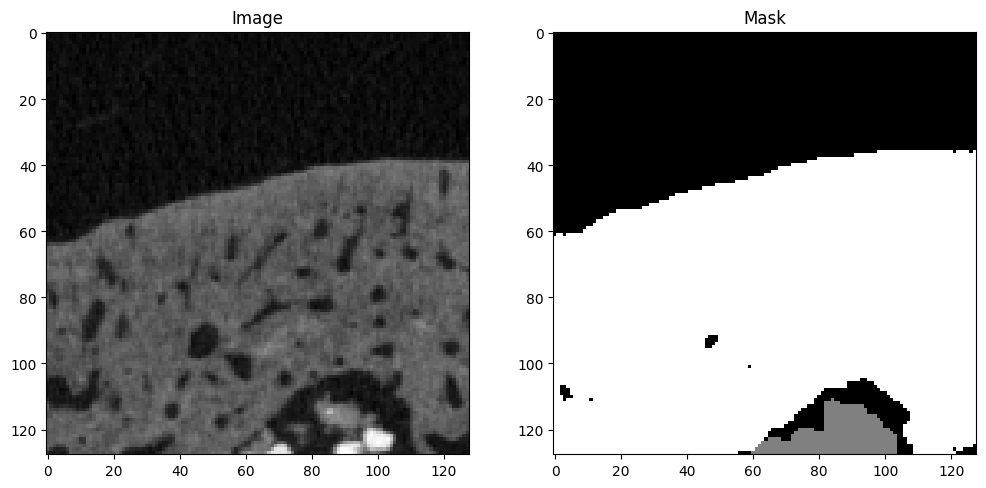

Image shape: torch.Size([1, 128, 128]), Mask shape: torch.Size([128, 128])


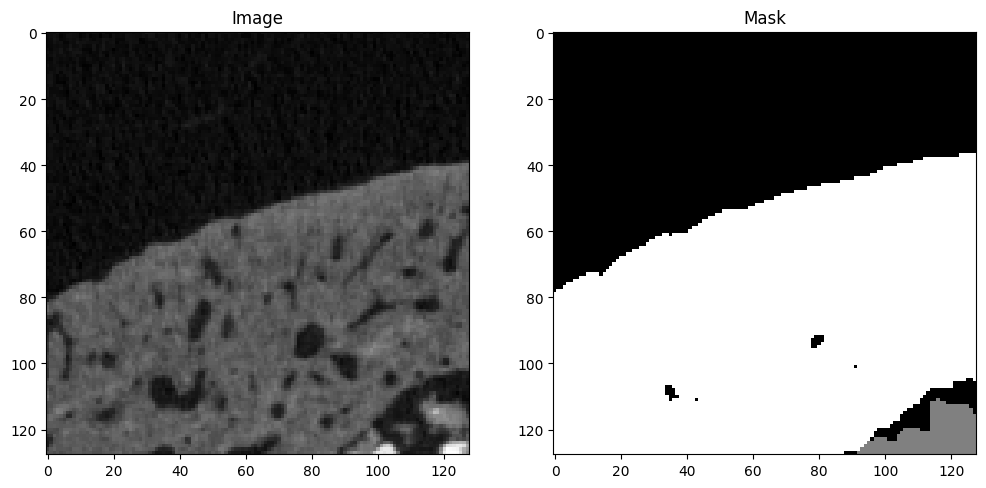

Image shape: torch.Size([1, 128, 128]), Mask shape: torch.Size([128, 128])


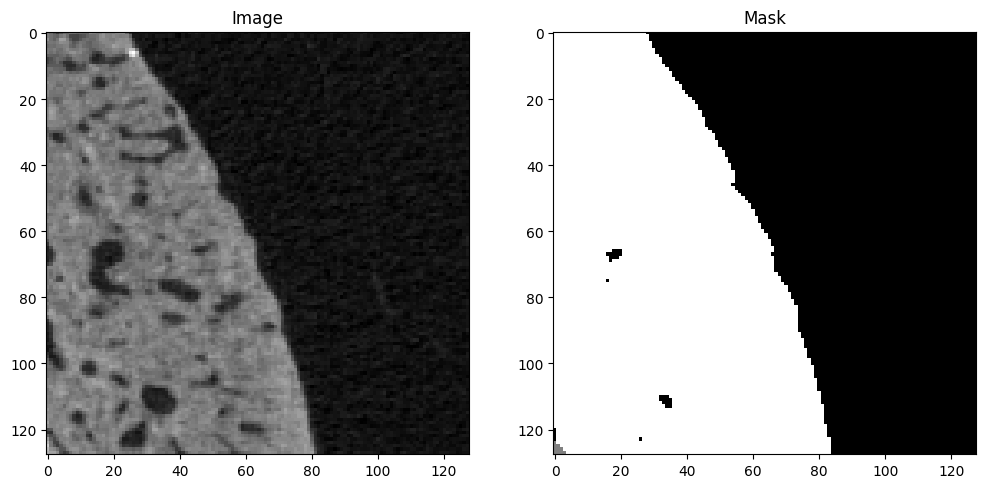

In [18]:
# Function to visualize a few patches from the training dataset
def visualize_patch(dataset, idx):
    sample = dataset[idx]
    image = sample['image']
    mask = sample['mask']
    print(f"Image shape: {image.shape}, Mask shape: {mask.shape}")
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.title("Image")
    
    if image.ndim == 2:
        plt.imshow(image, cmap='gray')
    elif image.ndim == 3:
        if image.shape[0] == 1:
            plt.imshow(image[0], cmap='gray')
        elif image.shape[0] == 3:
            plt.imshow(image.permute(1, 2, 0))
        elif image.shape[0] % 2 != 0:  # For odd number of channels
            middle_index = image.shape[0] // 2
            plt.imshow(image[middle_index], cmap='gray')
        else:  # For even number of channels
            composite_image = image[:3].permute(1, 2, 0)  # Using the first three channels
            plt.imshow(composite_image)
    
    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap='gray')
    
    plt.show()

# Example usage
for i in range(-3, 0):
    visualize_patch(train_data_loader.dataset, i)


# Validate Image Paths

In [19]:
# Validate paths to ensure all files are available
def validate_image_paths(image_paths):
    for path in image_paths:
        path = path.replace("\\", "/")
        if not os.path.exists(path):
            print(f"File does not exist: {path}")
            return False
    return True

# Example usage to validate all input images
input_image_paths = [os.path.join(new_input_dir, name).replace("\\", "/") for name in name_list]
if not validate_image_paths(input_image_paths):
    raise FileNotFoundError("One or more input image files are missing.")


In [20]:

net = UNet_Light_RDN(n_channels=n_channel, n_classes=class_num, dropout_rate=dropout_rate)
net.to(device)

# Log the model
mlflow.pytorch.log_model(net, "model")

c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


In [21]:
optimizer = Adam(net.parameters(),
                      lr=float(learning_rate),
                      eps=float(epsilon),
                      betas=(0.9, 0.999),
                      weight_decay=weight_decay)

#learning rate schedule
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=period_size, gamma=0.1)

# Journalisation des hyperparamètres de l'optimiseur
mlflow.log_param("optimizer", "Adam")
mlflow.log_param("betas", (0.9, 0.999))


(0.9, 0.999)

# Training loop

In [22]:
#rdn_train train the model for one iteration
# Input : 
# net: The neural network model being trained.
# optimizer: The optimizer used for updating the model's parameters.
# data_loader: DataLoader providing batches of training data.
# epoch: Current epoch number (optional).
# total_epoch: Total number of epochs (optional).
# tensorboard_plot: Boolean flag for visualizing results on TensorBoard (default is False).
#
# Output :
# returns the total number of iterations processed for this epoch (nb_ite + last_batches)

def visualize_images(writer, net, image, mask, device, nb_ite, last_batches, epoch):
    with torch.no_grad():
        pred2 = net(image)
    
    # Convert predictions and masks to 1-channel grayscale
    m2 = mask.argmax(1).cpu().squeeze().unsqueeze(1).float().numpy()
    pred2 = pred2.argmax(1).cpu().squeeze().unsqueeze(1).float().numpy()
    
    # Normalize the images for visualization
    input_img = image.cpu().numpy()
    
    if input_img.shape[1] > 3:  # More than 3 channels
        mid_slice = input_img.shape[1] // 2  # Middle slice
        input_img = input_img[:, mid_slice:mid_slice+3, :, :]
    
    writer.add_image('input_image', torchvision.utils.make_grid(torch.tensor(input_img), normalize=True, scale_each=True), nb_ite + last_batches)
    writer.add_image('mask_image', torchvision.utils.make_grid(torch.tensor(m2), normalize=True, scale_each=True), nb_ite + last_batches)
    writer.add_image('prediction_image', torchvision.utils.make_grid(torch.tensor(pred2), normalize=True, scale_each=True), nb_ite + last_batches)



In [23]:
    

# Updated rdn_train function to include visualize_entire_batch
def rdn_train(net, optimizer, data_loader, epoch=None, total_epoch=None, tensorboard_plot=False, nb_ite=0):
    max_batches1 = len(data_loader.dataset) // data_loader.batch_size + (1 if (len(data_loader.dataset) % data_loader.batch_size) != 0 else 0)
    epoch_print = 'Epoch:'
    if epoch is not None:
        epoch_print += f'{epoch + 1}'
    if total_epoch is not None:
        epoch_print += f'/{total_epoch}'
    last_batches = 0.0
    loss1_sum = 0.0
    loss2_sum = 0.0
    ite = 0

    writer = SummaryWriter(tensorboard_logs_dir)  # Move writer instantiation here

    with tqdm(total=len(data_loader.dataset), desc=epoch_print, unit=' batches') as pbar:
        for i_batches, sample_batched in enumerate(data_loader):
            last_batches = i_batches
            mask = sample_batched['mask']
            image = sample_batched['image']
            mask = mask.to(device).long()
            image = image.to(device)
            pred = net(image)
            loss1 = torch.Tensor(0)
            mask = create_one_hot(mask)
            if tensorboard_plot and nb_ite + ite == 0:
                writer.add_graph(net, image)
            if tensorboard_plot and (ite % (max_batches1 // 3) == 0):
                visualize_images(writer, net, image, mask, device, nb_ite, last_batches, epoch)
            CE_loss = nn.CrossEntropyLoss()
            loss2 = CE_loss(pred, mask)
            loss2.to(device)
            optimizer.zero_grad()
            loss2.backward()
            optimizer.step()
            pbar.update(mask.shape[0])
            pbar.set_postfix(loss=loss2.cpu().data.numpy(), loss1=loss1.cpu().data.numpy(), loss2=loss2.cpu().data.numpy())
            loss1_sum += loss1.cpu().data.numpy()
            loss2_sum += loss2.cpu().data.numpy()
            ite += 1

        avg_loss2 = loss2_sum / (last_batches + 1)
        print(f'\nAverage, loss2: {(loss2_sum / (last_batches + 1)):.6f}.')
        mlflow.log_metric("avg_train_loss2", avg_loss2, step=epoch)
    
    writer.close()
    return nb_ite + last_batches









#rdn_val test the accuracy of the model for the current epoch
# Input :
# net: The neural network model.
# data_set: The dataset for validation.
# i_epoch: Current epoch number (optional).
# class_num: Number of classes in the dataset (default is 3).
#
# Output :
# returns the average accuracy (criterion_value) and class-wise dice overlap results.

class DiceOverlap():
    def __init__(self, class_num):
        self.len = class_num

    def __call__(self, input, target):
        input = F.sigmoid(input)
        input = torch.max(input, 1)[1]

        dice = []

        for i in range(self.len):
            sub_target = torch.zeros(target.shape).cuda()
            sub_target[target == i] = 1
            sub_input = torch.zeros(input.shape).cuda()
            sub_input[input == i] = 1

            tp_idx = target == i

            eps = 0.0001
            tp = torch.sum(sub_input[tp_idx] == sub_target[tp_idx])
            fn = torch.sum(sub_input != sub_target)
            tp = tp.float()
            fn = fn.float()
            result = (2 * tp + eps) / (2 * tp + fn + eps)
            dice.append(result.cpu().data.numpy())

        return np.asarray(dice)


class Accuracy():
    def __call__(self, input, target, **kwargs):
        input = torch.max(input, 1)[1]
        size = 1
        for i in range(len(input.shape)):
            size = size * input.shape[i]
        return torch.sum(input == target).float() / size

def rdn_val(net, dataloader, i_epoch=None, class_num=3):
    dice_overlap = DiceOverlap(class_num)
    origin_is_train_mode = net.training
    if origin_is_train_mode:
        net.eval()
    
    criterion_value_sum = 0.0
    data_loader = DataLoader(dataloader.dataset, batch_size=1, num_workers=0)  # Create a DataLoader with num_workers=0
    dice_overlap_results = np.zeros(class_num)
    
    with torch.no_grad():
        for i_batches, sample_batched in enumerate(data_loader):
            mask = sample_batched['mask']
            image = sample_batched['image']
            mask = mask.to(device)
            image = image.to(device)
            pred = net(image)
            criterion_value_sum += Accuracy()(pred, mask.long()).cpu().data.numpy()
            if dice_overlap is not None:
                dice_result = dice_overlap(pred, mask.long())
                dice_overlap_results += dice_result
    
    if len(data_loader.dataset) > 0:
        criterion_value = criterion_value_sum / len(data_loader.dataset)
        dice_overlap_results = dice_overlap_results / len(data_loader.dataset)
    else:
        criterion_value = 0.0
        dice_overlap_results = np.zeros(class_num)
    
    if origin_is_train_mode:
        net.train()
    
    mlflow.log_metric("val_accuracy", criterion_value, step=i_epoch)
    for i in range(dice_overlap_results.shape[0]):
        mlflow.log_metric(f"dice_overlap_class_{i}", dice_overlap_results[i], step=i_epoch)
    
    if i_epoch is not None:
        print(f"Epoch: {i_epoch + 1}, Accuracy Value: {criterion_value:.6f}")
        writer.add_scalar('Accuracy Value', criterion_value, i_epoch)
        writer.add_scalars('Dice Overlap', {
            'Air': dice_overlap_results[0], 
            'Dirt': dice_overlap_results[1], 
            'Bone': dice_overlap_results[2]
        }, i_epoch)
    
    return criterion_value, dice_overlap_results










In [24]:
# Training loop
nested_metrics = {
    'train_loss': [],
    'val_accuracy': [],
    'dice_overlap_class_0': [],
    'dice_overlap_class_1': [],
    'dice_overlap_class_2': []
}

epoch_count = 0
print(f"Epoch progress:")
print(f"Progress training {epochs_num} epochs...")
total_timer = timer()
iteration = 0
nb_ite = 0



# Training loop
for i_epoch in range(epochs_num):
    nested_runs_dir = os.path.join(tensorboard_logs_dir, f"epoch_{i_epoch + 1}")
    writer = SummaryWriter(nested_runs_dir)
    with mlflow.start_run(nested=True, run_name=f"epoch_{i_epoch + 1}"):
        print(f"Epoch {epoch_count + 1} of {epochs_num}")

        # Dynamic air rate based on epoch
        if i_epoch < period_size:
            air_rate = 0.1
        elif i_epoch < 2 * period_size:
            air_rate = 0.2
        elif i_epoch < 3 * period_size:
            air_rate = 0.4
        else:
            air_rate = 0.5

        mlflow.log_param("air_rate", air_rate)

        # Debug: Print lengths of patches arrays after dirt filtering
        print(f"Patches after dirt filtering: {len(filtered_train_patches)}")

        # Use the normal train_patches and train_dataset
        train_dataset = HDF52D(filtered_train_patches, input_list, label_list, transform=train_transform, n_channels=n_channel, step=step, mode='train')
        train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)  # Change: num_workers=0

        print(f"Learning rate {optimizer.param_groups[0]['lr']:.6f}")
        nb_ite = rdn_train(net, optimizer, train_data_loader, epoch=i_epoch, total_epoch=epochs_num, tensorboard_plot=True, nb_ite=nb_ite)

        # Validation
        val_dataset = HDF52D(filtered_val_patches, input_list, label_list, transform=val_transform, n_channels=n_channel, step=step, mode='val')
        val_data_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        # Collect validation metrics for the current epoch
        val_loss, class_val = rdn_val(net, val_data_loader, class_num=class_num)
        nested_metrics['val_accuracy'].append(val_loss)
        for i, class_val_metric in enumerate(class_val):
            nested_metrics[f'dice_overlap_class_{i}'].append(class_val_metric)

        class_val = pd.DataFrame(class_val)
        class_val.columns = ["Class Dice overlap"]
        print(class_val)
        epoch_count += 1
        iteration = np.floor((100 * epoch_count) / int(epochs_num))

# Save model
torch.save(net.state_dict(), "RDN_adapted.pth")

# Aggregate and log metrics from nested runs to the main run
avg_train_loss = np.mean(nested_metrics['train_loss'])
avg_val_accuracy = np.mean(nested_metrics['val_accuracy'])
avg_dice_overlap_class_0 = np.mean(nested_metrics['dice_overlap_class_0'])
avg_dice_overlap_class_1 = np.mean(nested_metrics['dice_overlap_class_1'])
avg_dice_overlap_class_2 = np.mean(nested_metrics['dice_overlap_class_2'])

mlflow.log_metric("avg_train_loss", avg_train_loss)
mlflow.log_metric("avg_val_accuracy", avg_val_accuracy)
mlflow.log_metric("avg_dice_overlap_class_0", avg_dice_overlap_class_0)
mlflow.log_metric("avg_dice_overlap_class_1", avg_dice_overlap_class_1)
mlflow.log_metric("avg_dice_overlap_class_2", avg_dice_overlap_class_2)

# End MLflow run
mlflow.end_run()

# Close the TensorBoard writer
writer.close()

# Set num_workers to 0 to avoid multiprocessing for final DataLoaders
train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_data_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


Epoch progress:
Progress training 3 epochs...
Epoch 1 of 3
Patches after dirt filtering: 3680
Learning rate 0.001000


Epoch:1/3:   0%|          | 0/3680 [00:00<?, ? batches/s]C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_23752\3280858929.py:65: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  diffY = torch.tensor([x2.size()[2] - x1.size()[2]])
C:\Users\n.vanderesse\AppData\Local\Temp\ipykernel_23752\3280858929.py:66: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  diffX = torch.tensor([x2.size()[3] - x1.size()[3]])
Epoch:1/3: 100%|██████████| 3680/3680 [00:21<00:00, 173.44 batches/s, loss=0.32


Average, loss2: 0.400235.
   Class Dice overlap
0            0.822591
1            0.737383
2            0.720020
Epoch 2 of 3
Patches after dirt filtering: 3680
Learning rate 0.001000


Epoch:2/3: 100%|██████████| 3680/3680 [00:18<00:00, 198.53 batches/s, loss=0.36296695, loss1=[], loss2=0.36296695]



Average, loss2: 0.304120.
   Class Dice overlap
0            0.863947
1            0.513104
2            0.712078
Epoch 3 of 3
Patches after dirt filtering: 3680
Learning rate 0.001000


Epoch:3/3: 100%|██████████| 3680/3680 [00:18<00:00, 197.88 batches/s, loss=0.37067038, loss1=[], loss2=0.37067038]



Average, loss2: 0.307634.
   Class Dice overlap
0            0.879770
1            0.506500
2            0.696965


c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\n.vanderesse\AppData\Local\ia-sereos_env\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [25]:
# Set num_workers to 0 to avoid multiprocessing
train_data_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_data_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)



# Function to inspect predictions
def inspect_predictions(dataloader, model, device):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            image = sample['image'].to(device)
            mask = sample['mask'].to(device)

            # Make predictions
            output = model(image)
            preds = output.argmax(dim=1)

            # Move predictions to CPU and convert to numpy array
            preds = preds.cpu().numpy()

            # Inspect unique values in the predictions
            unique_values = np.unique(preds)
            print(f"Unique values in predictions for batch {i}: {unique_values}")

            if i == 0:  # Inspect only the first batch for now
                break

# Example usage with your validation DataLoader
inspect_predictions(val_data_loader, net, device)

Unique values in predictions for batch 0: [0 1 2]


Unique values in predictions: [0 1 2]
Unique values in ground truth masks: [0 1 2]
Input batch shape: torch.Size([32, 1, 128, 128])
Mask batch shape: torch.Size([32, 128, 128])
Prediction batch shape: (32, 128, 128)


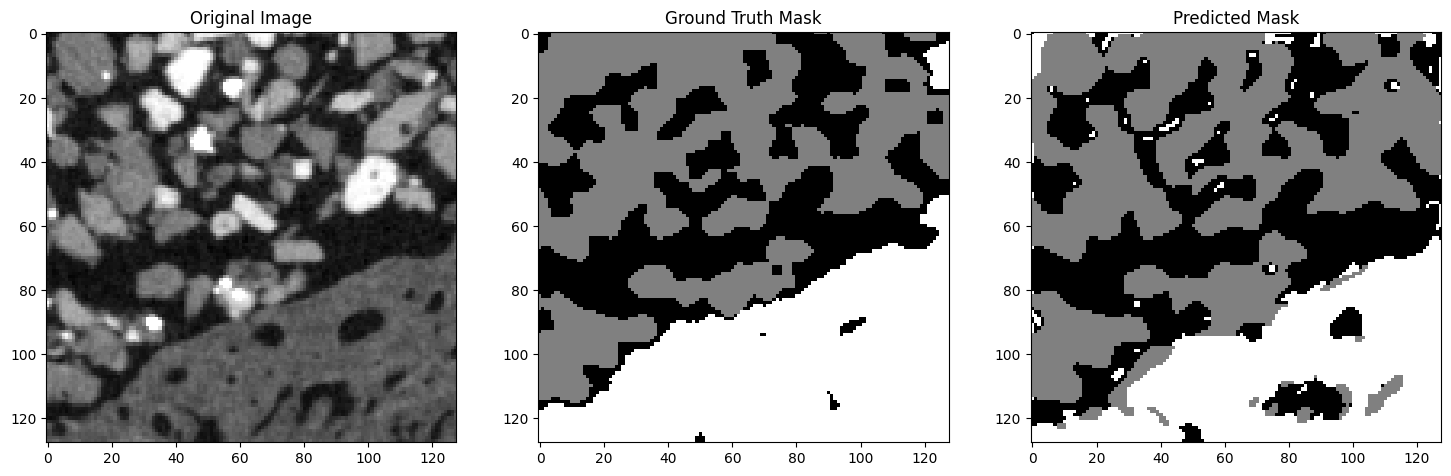

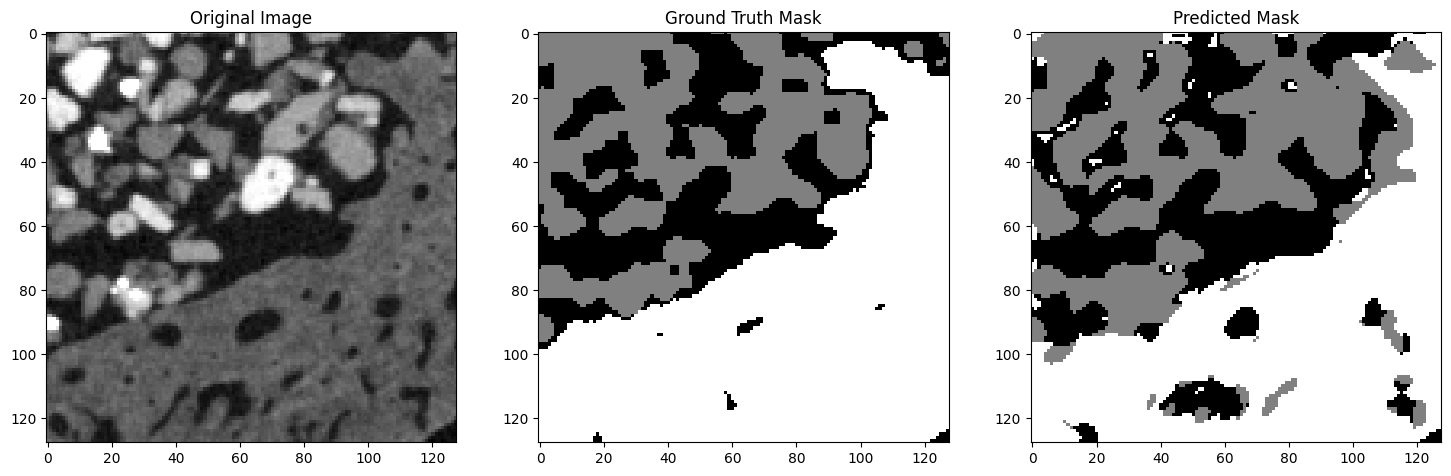

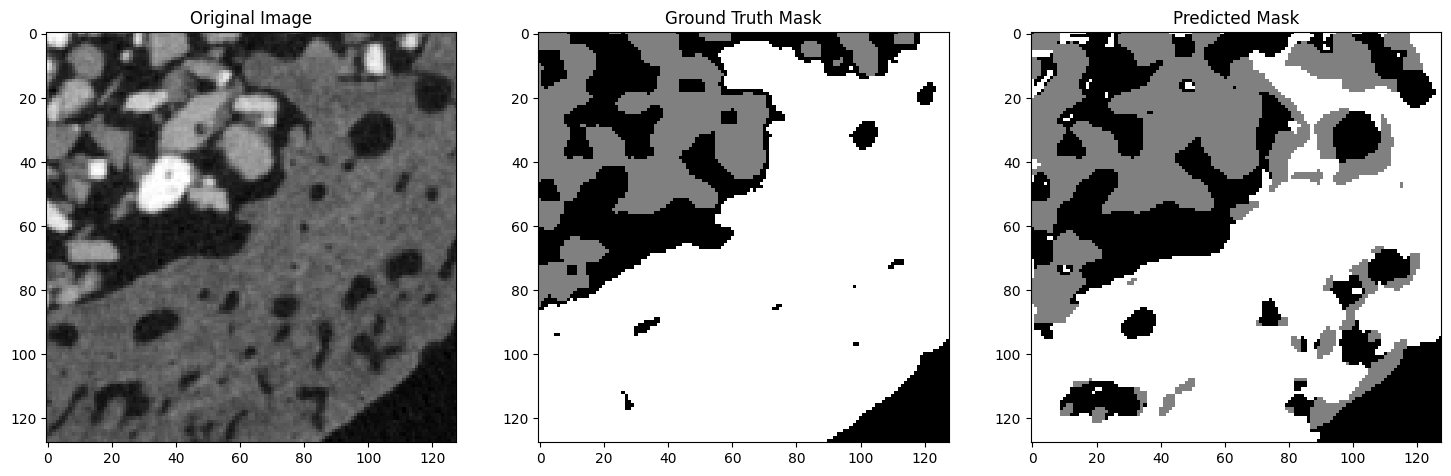

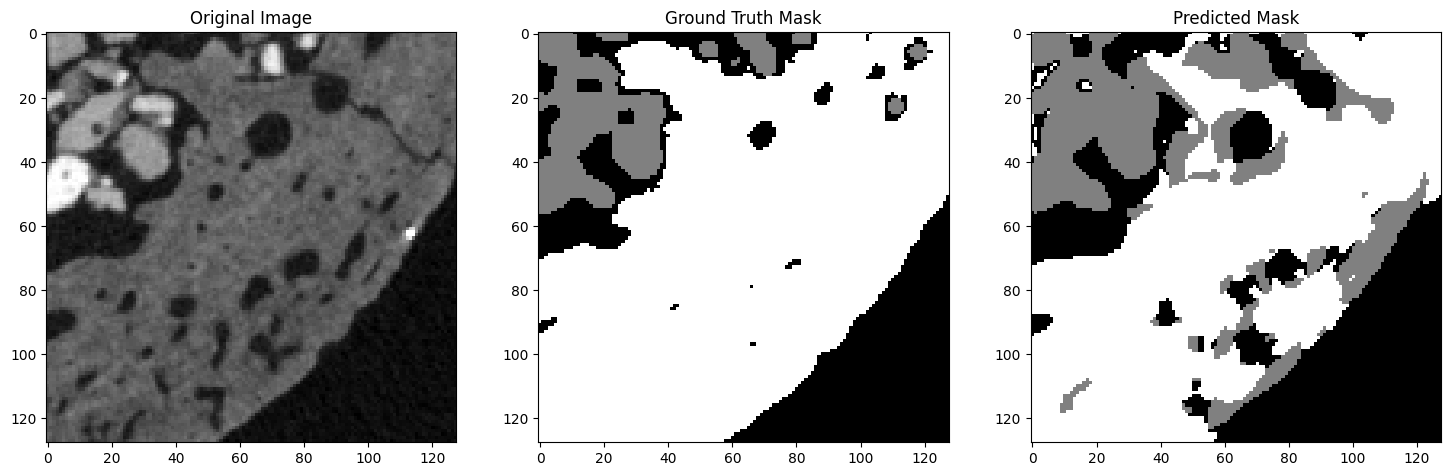

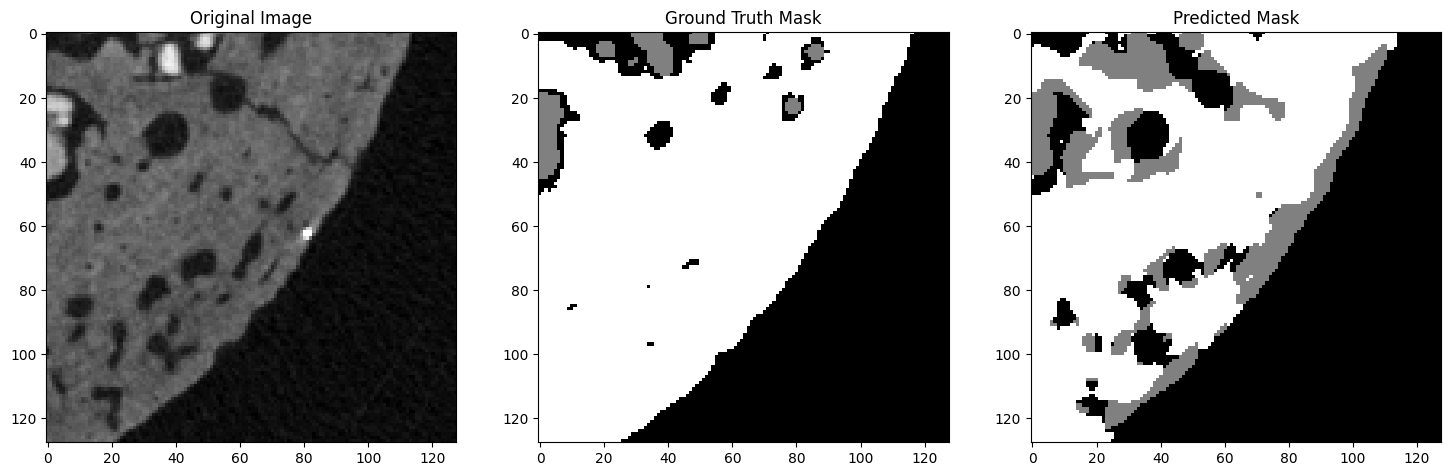

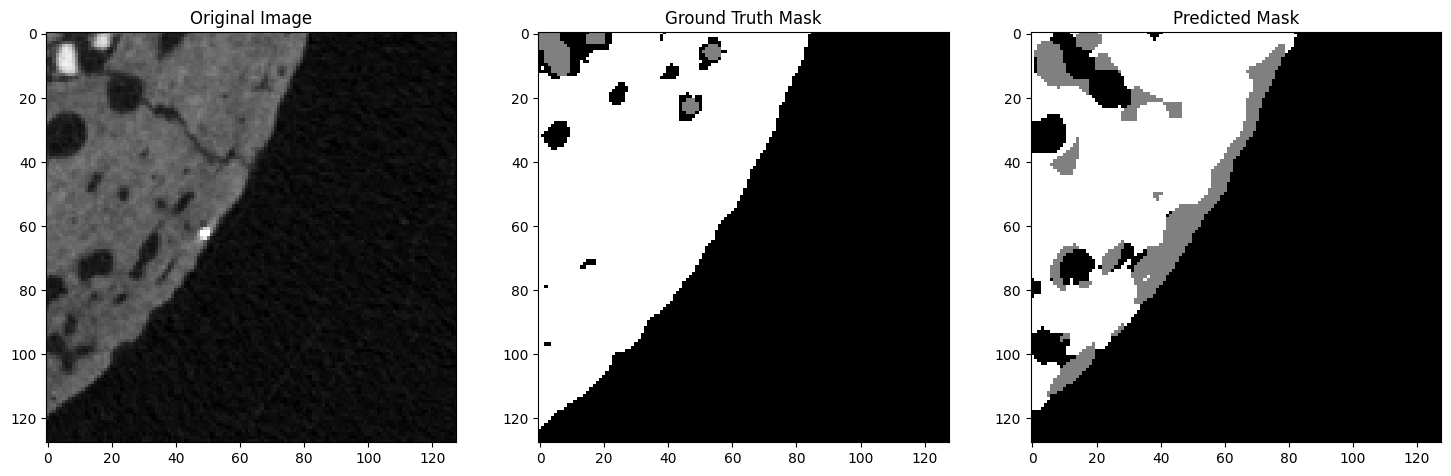

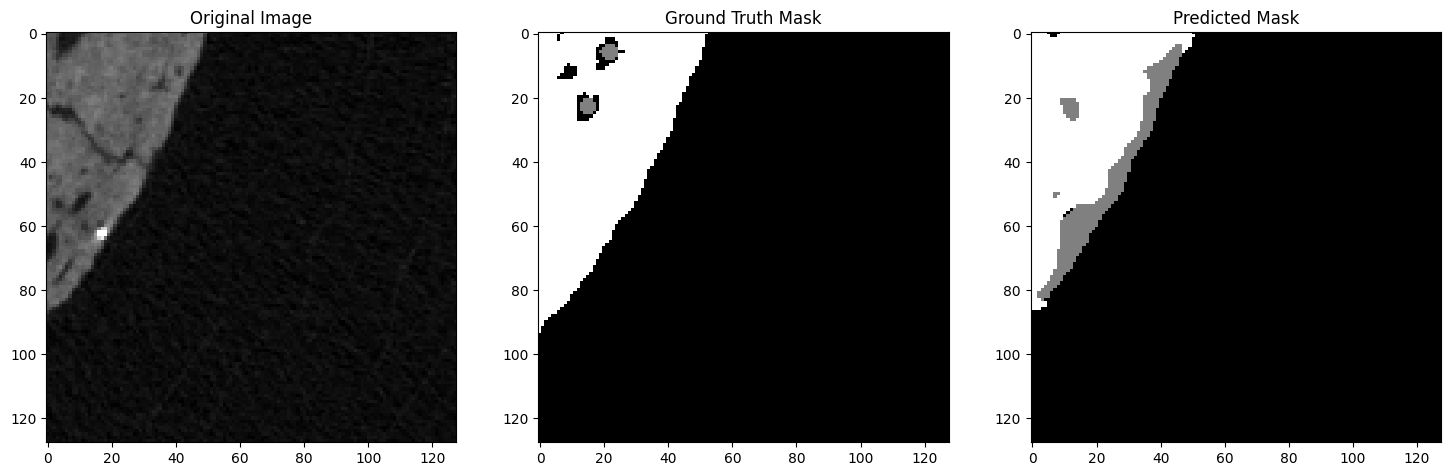

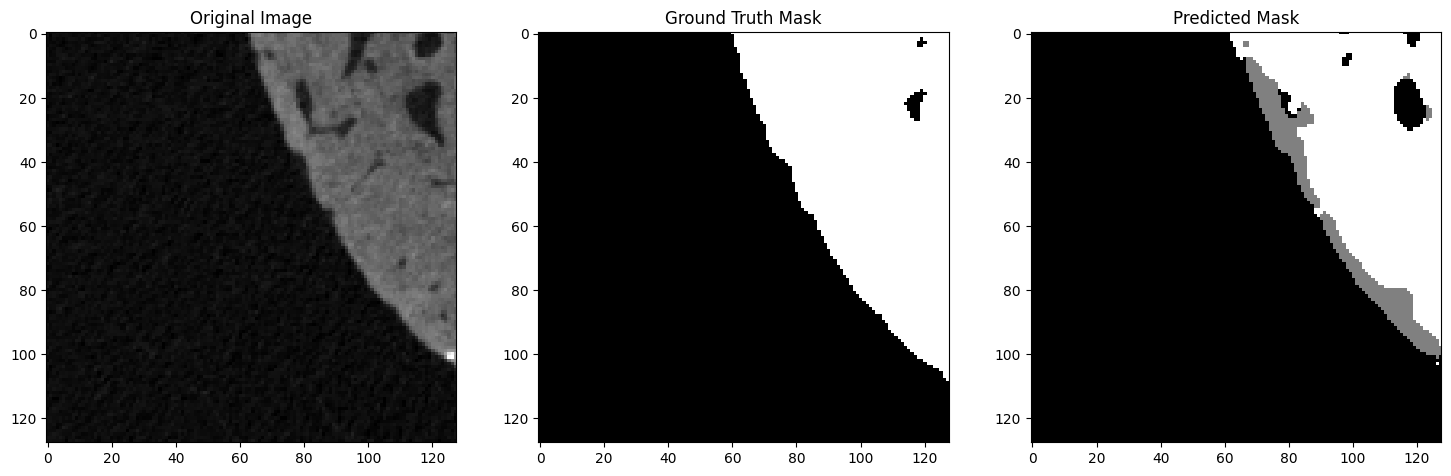

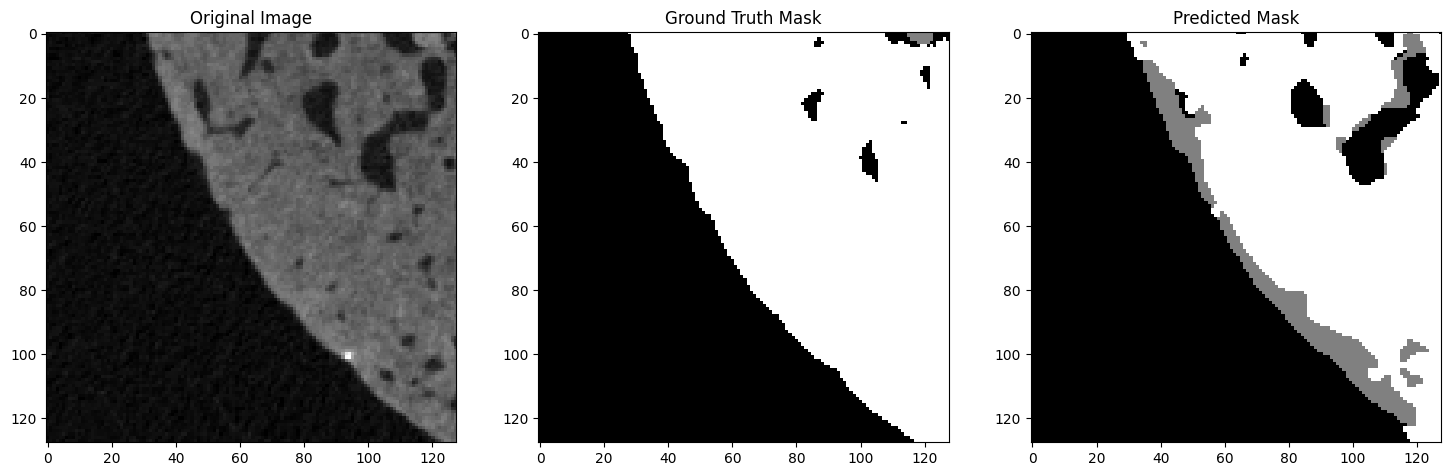

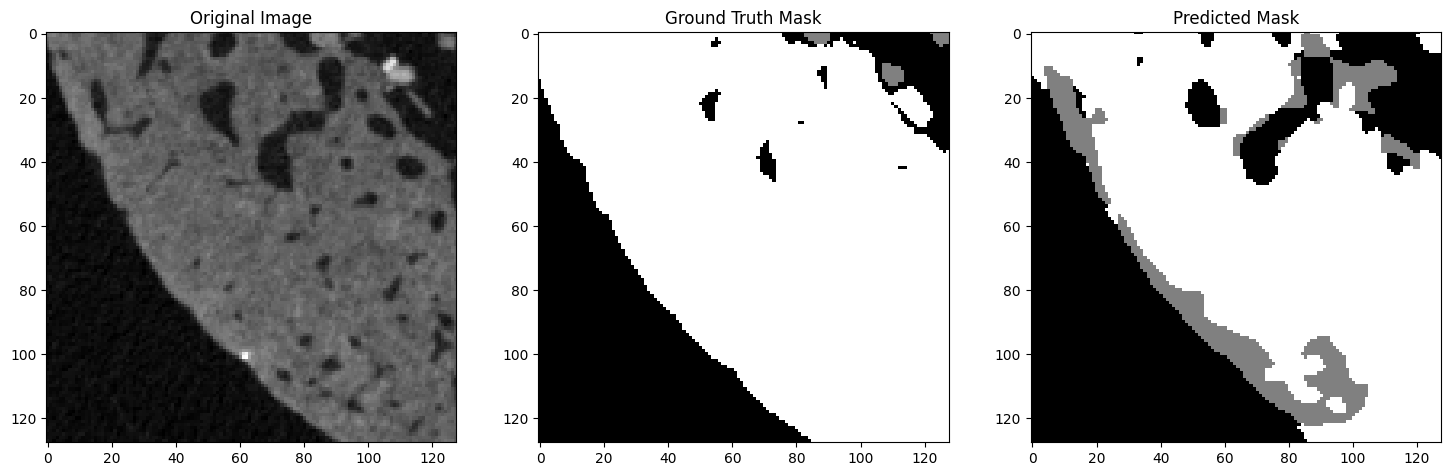

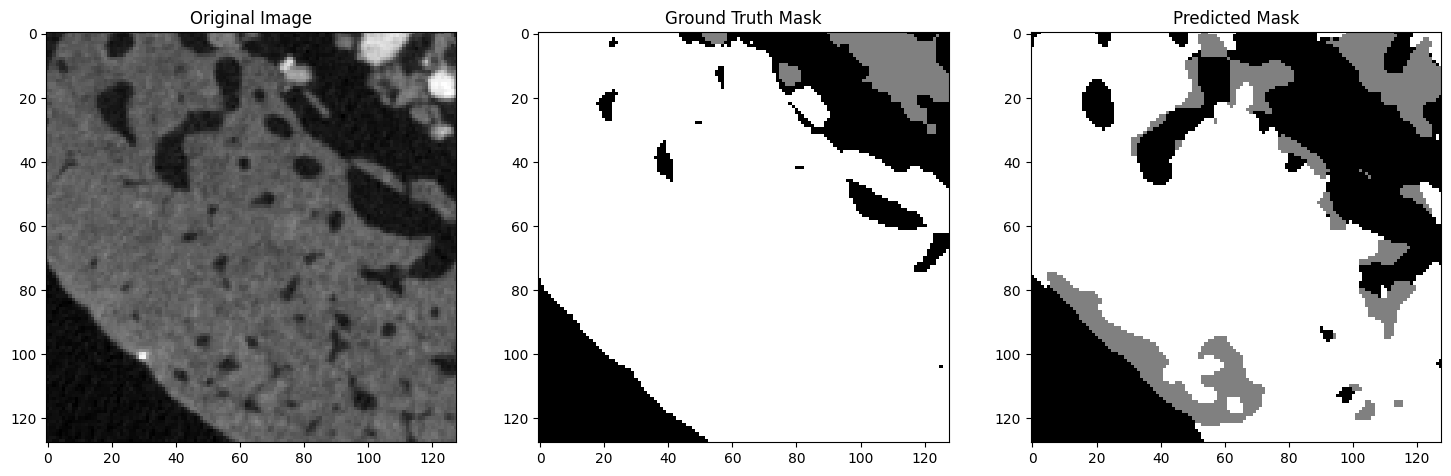

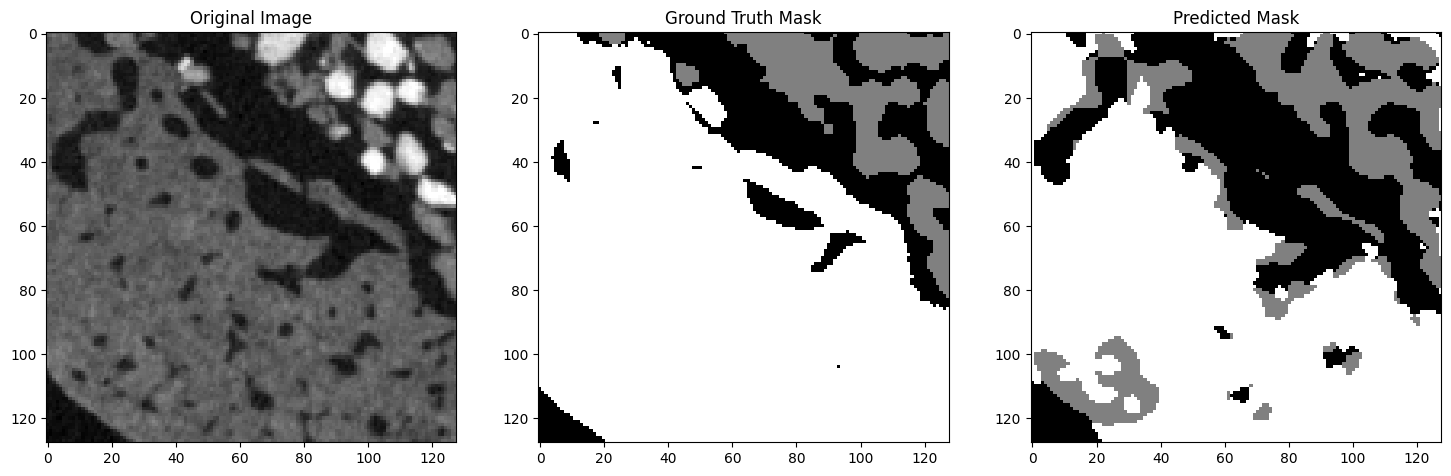

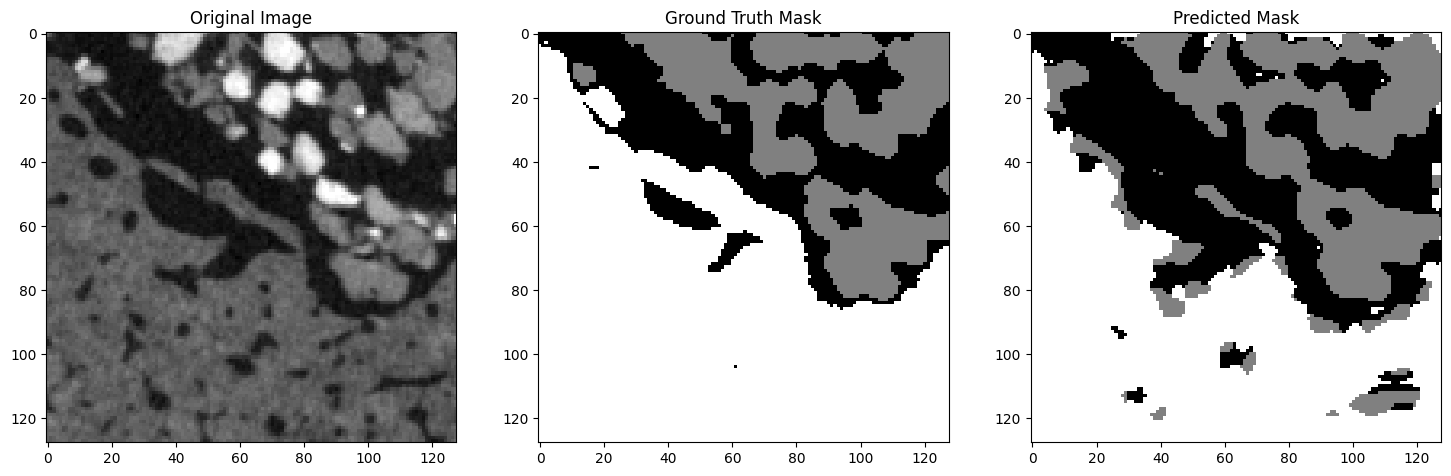

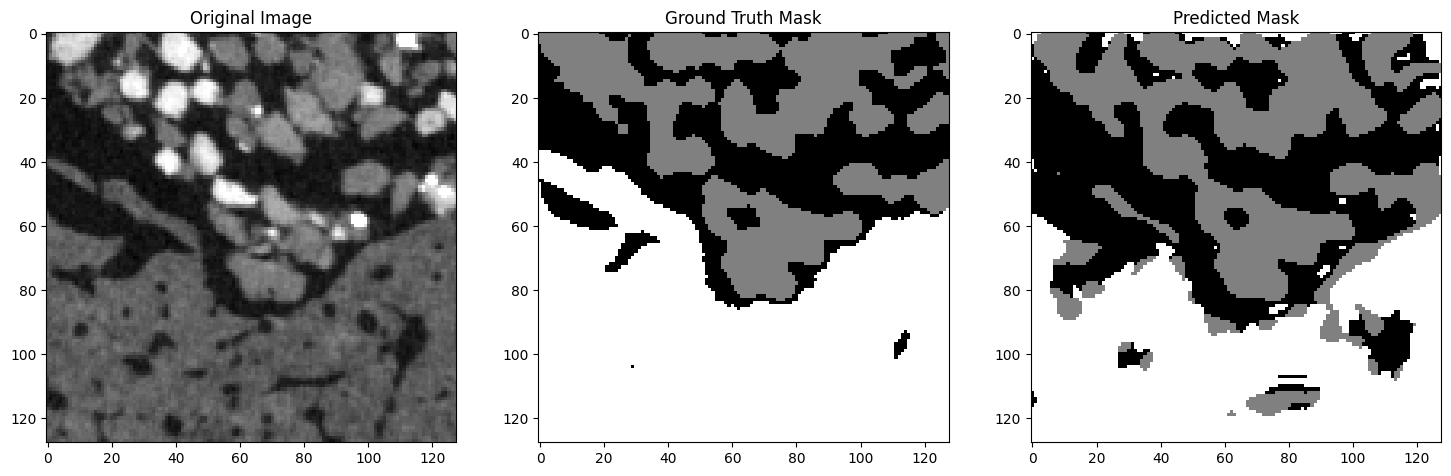

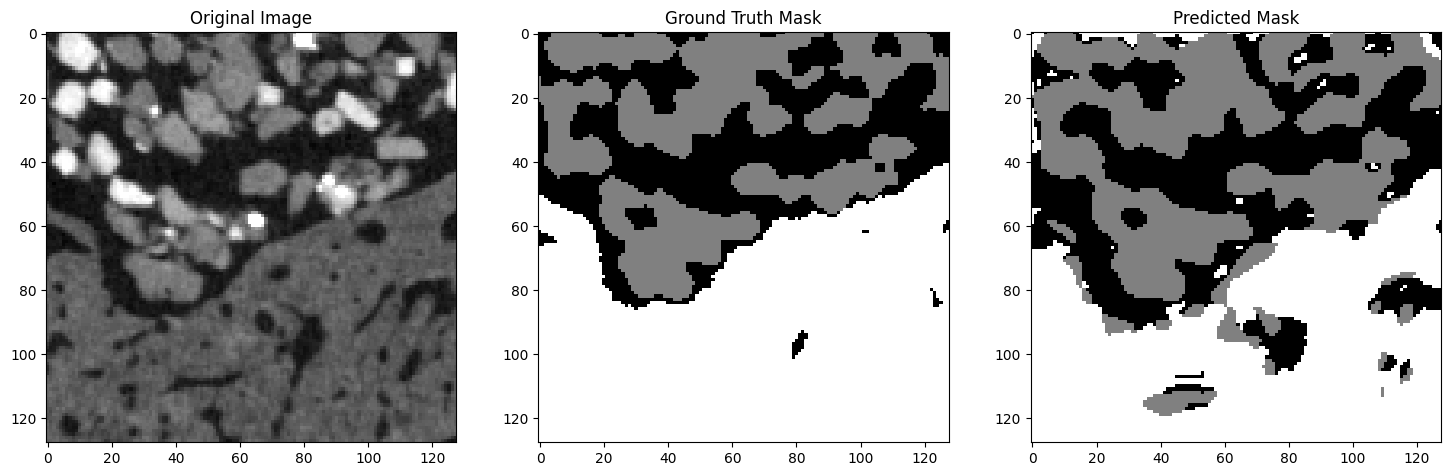

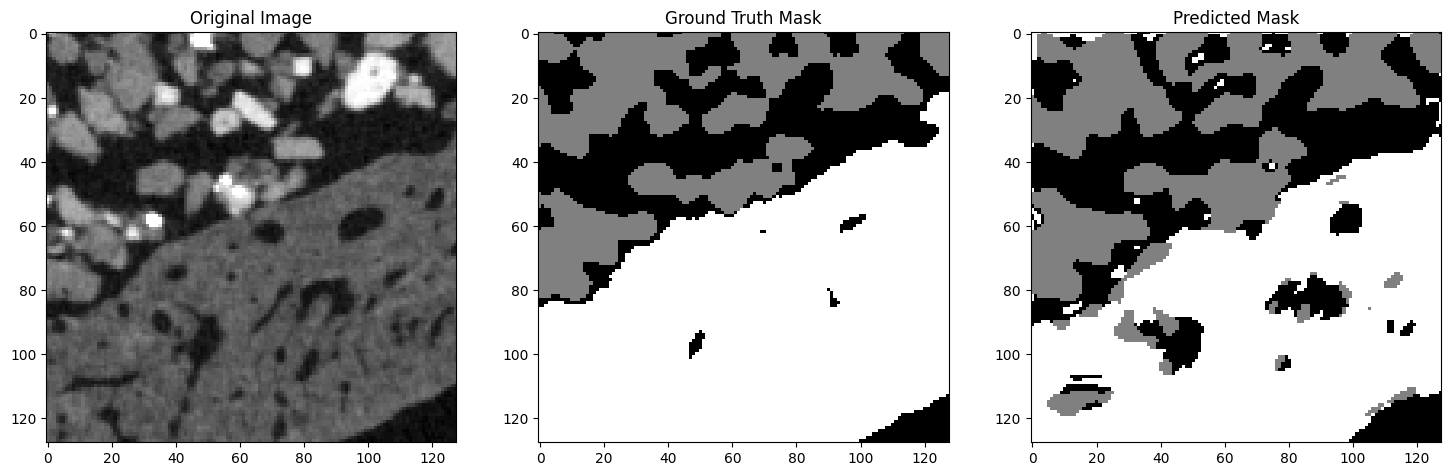

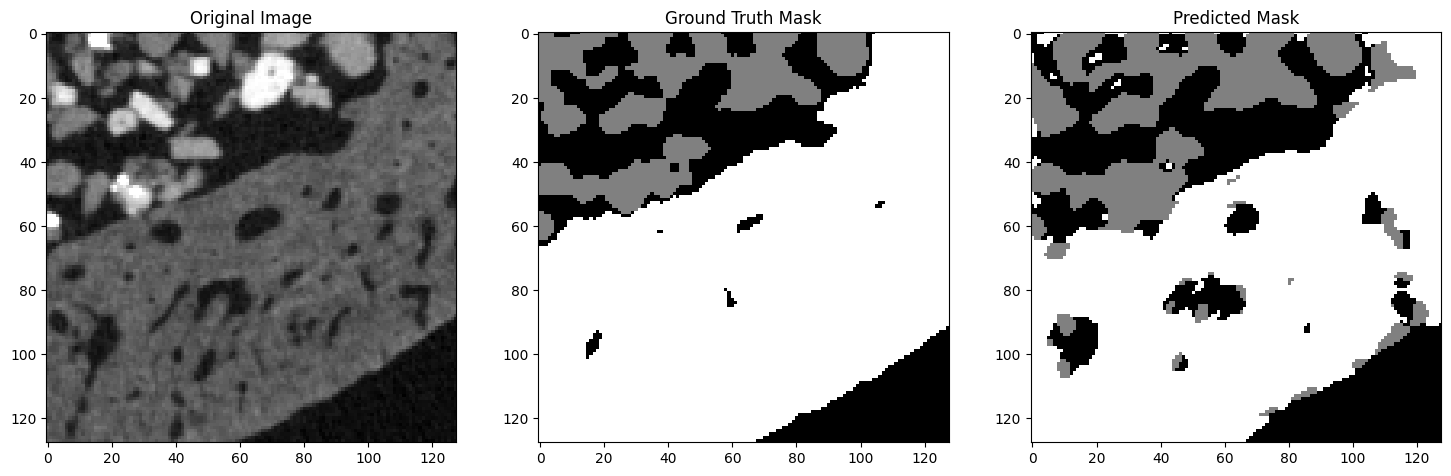

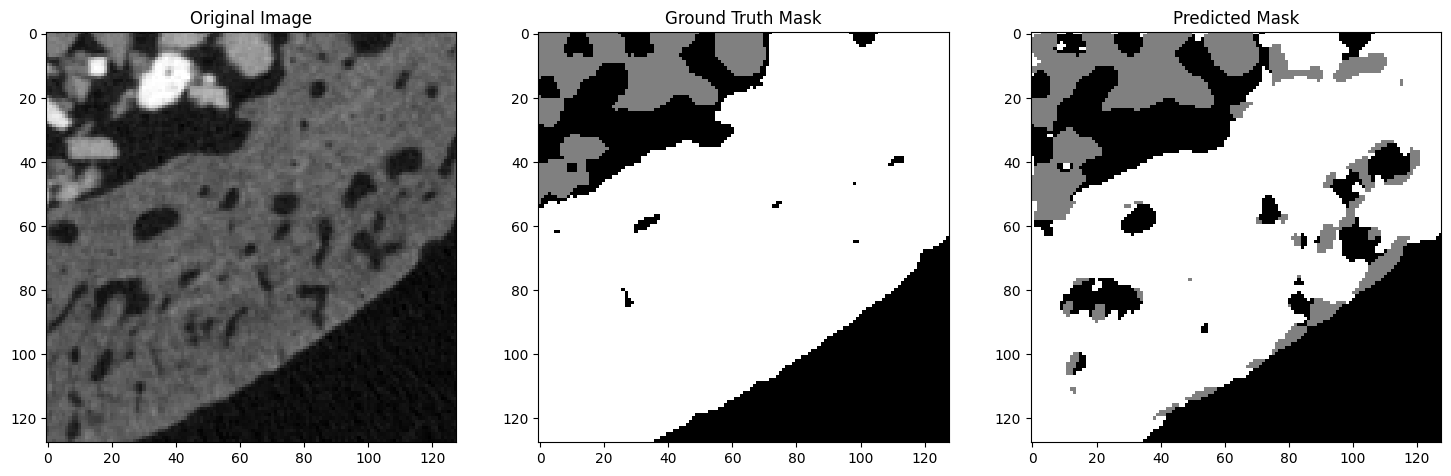

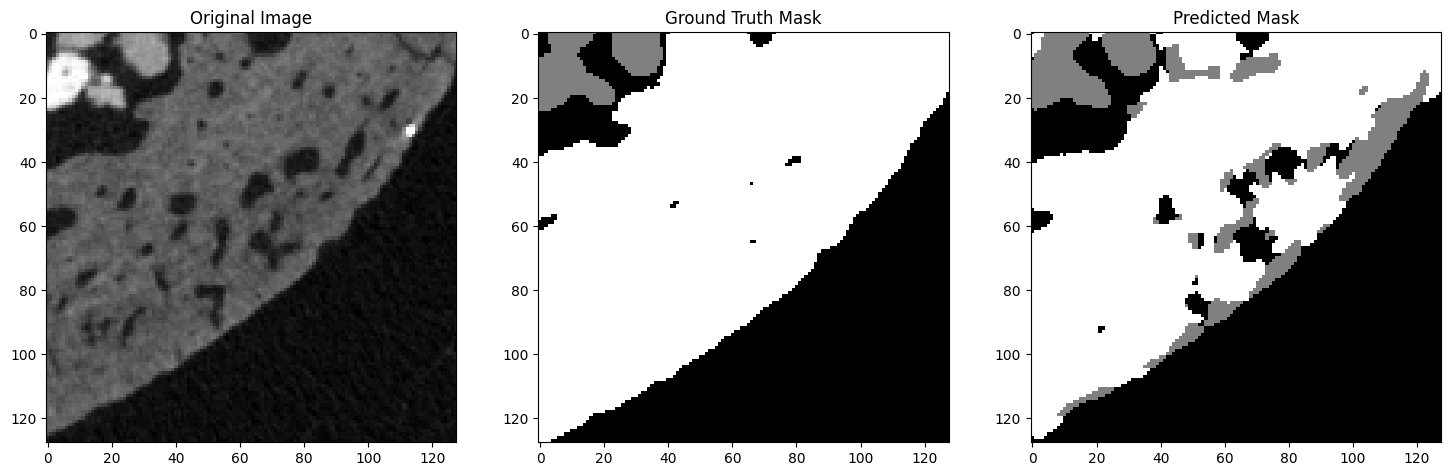

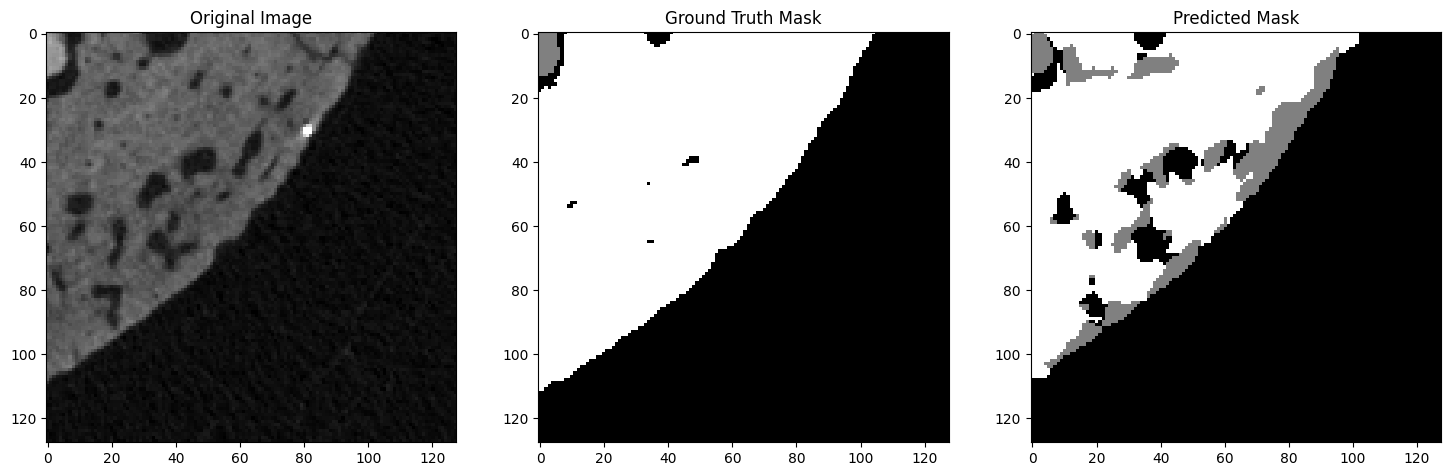

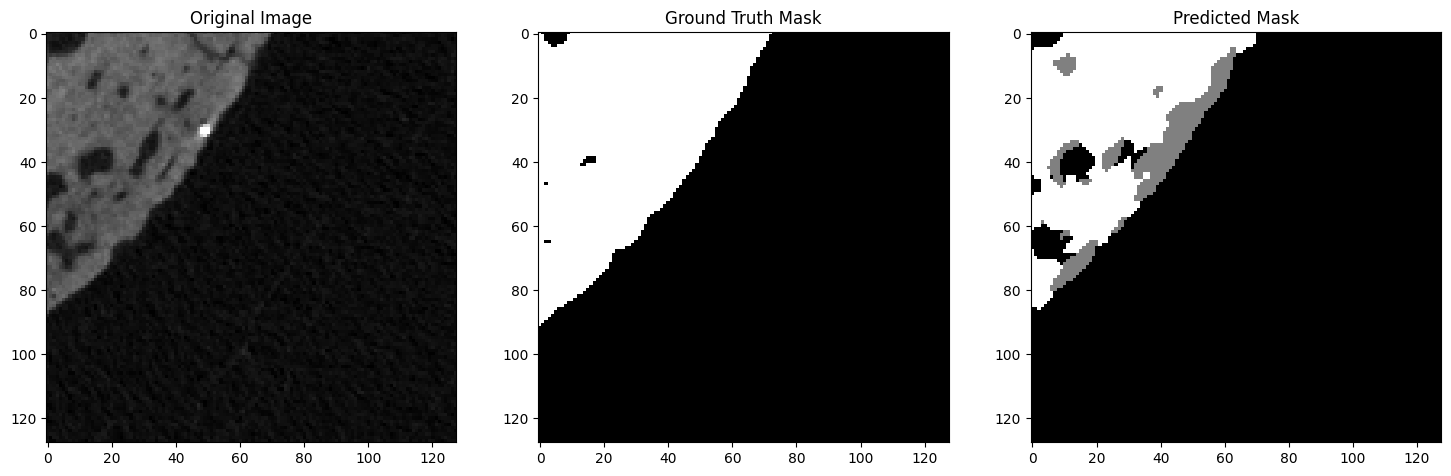

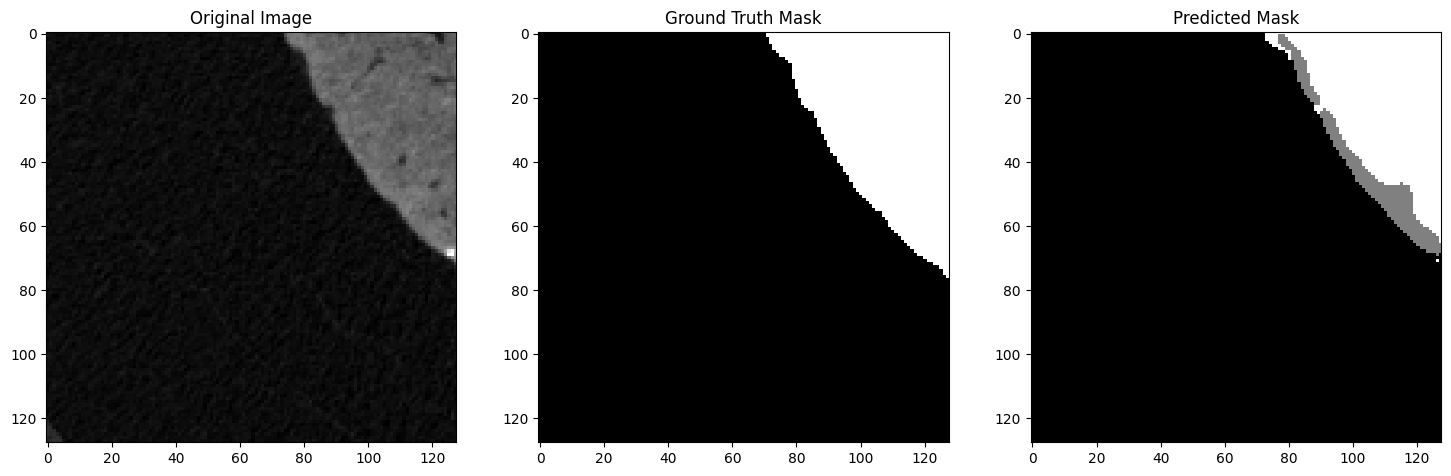

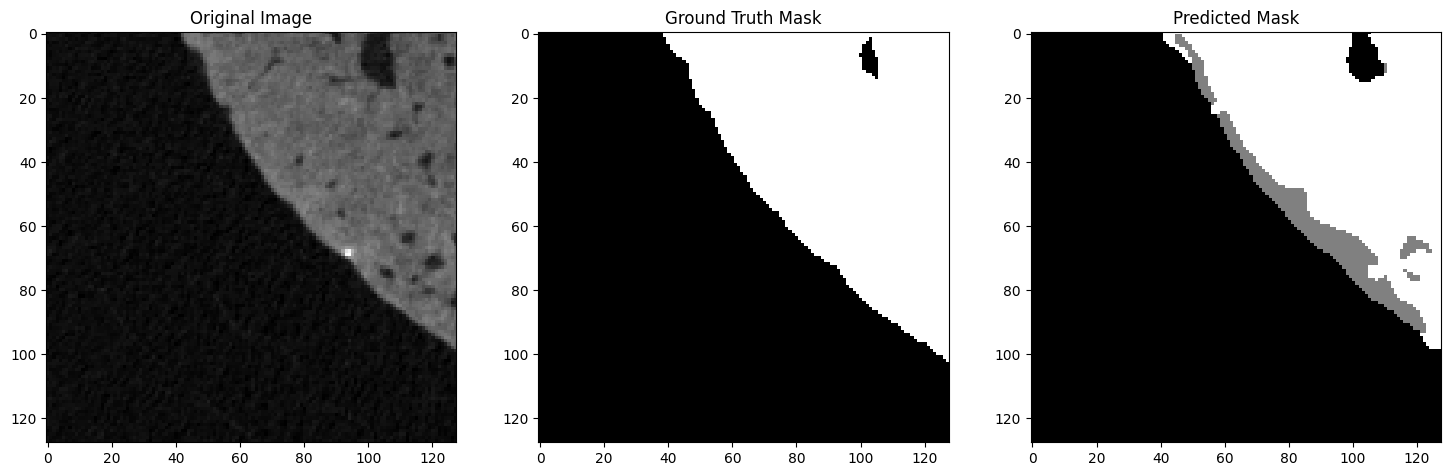

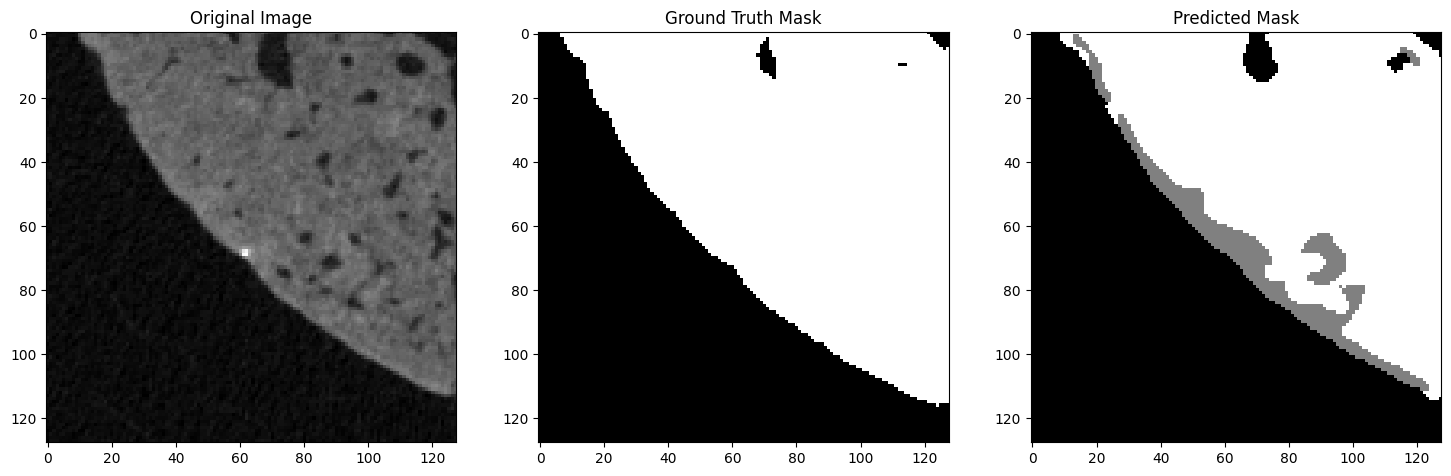

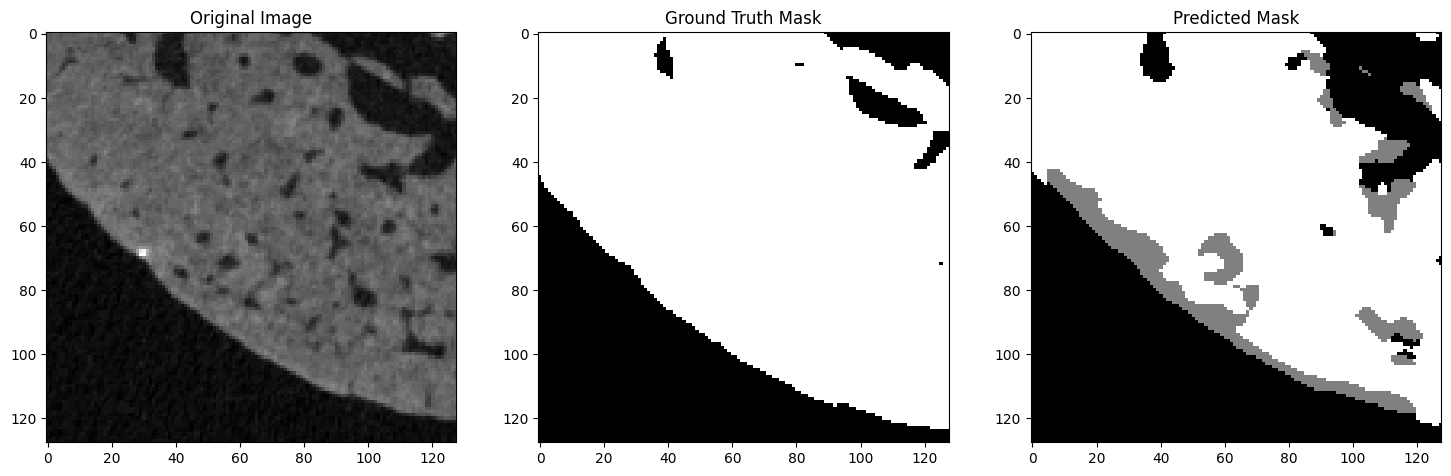

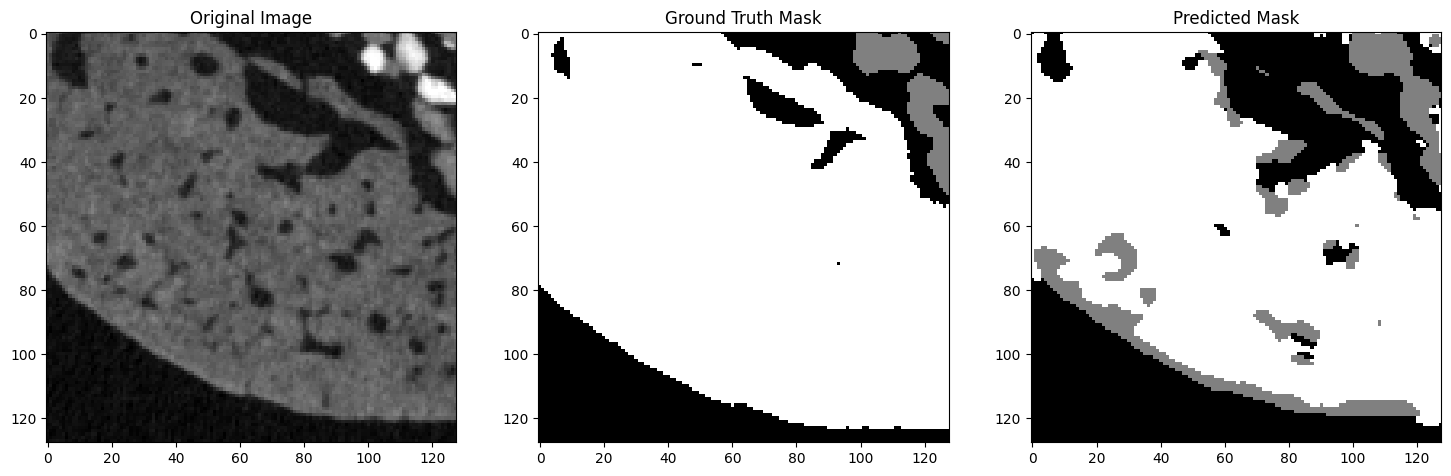

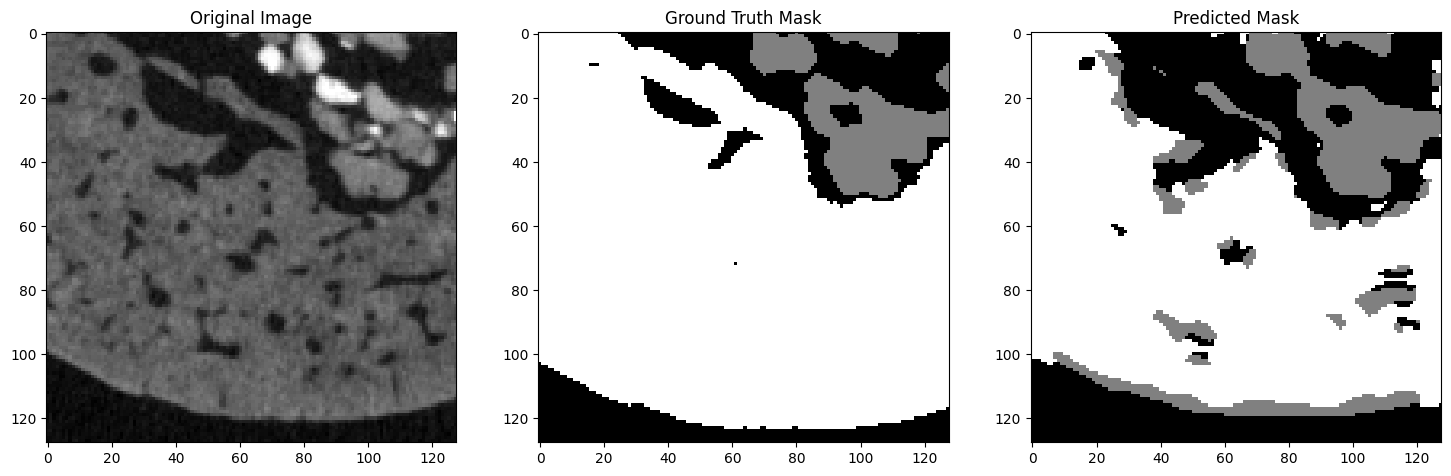

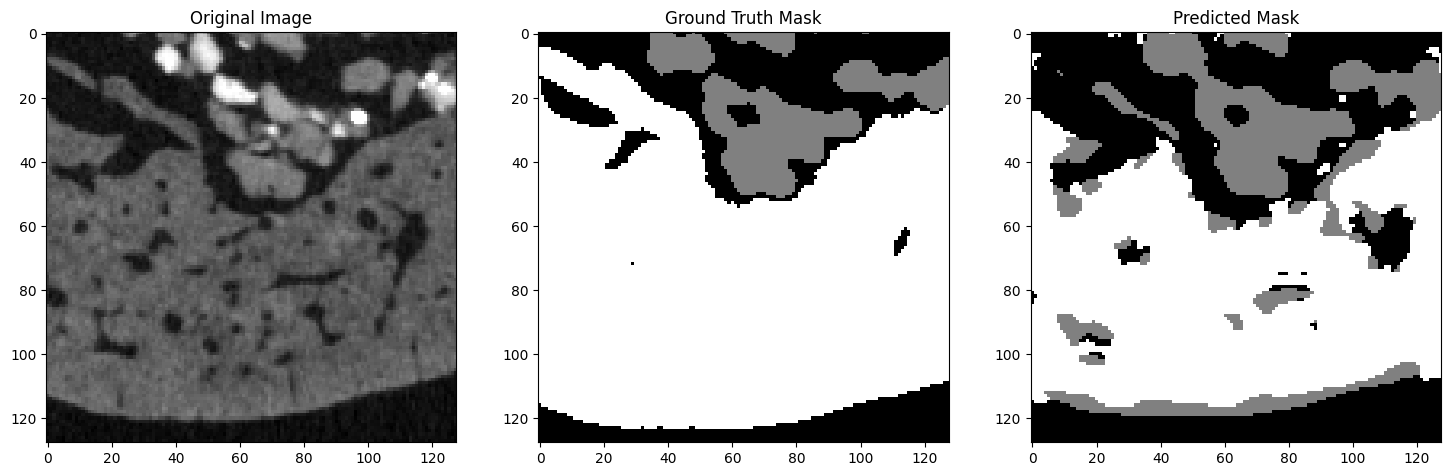

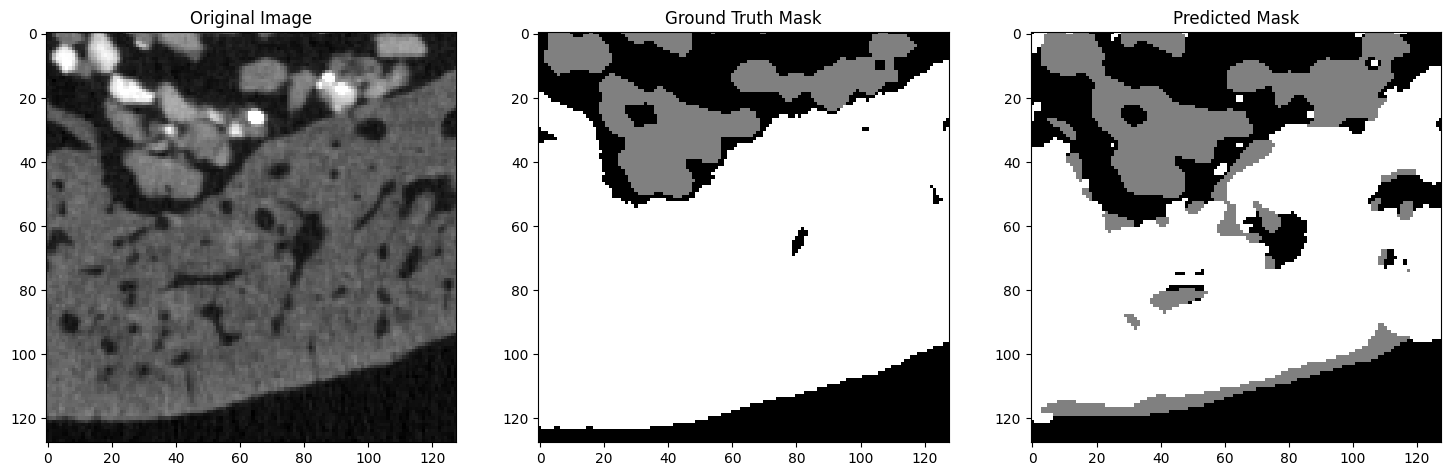

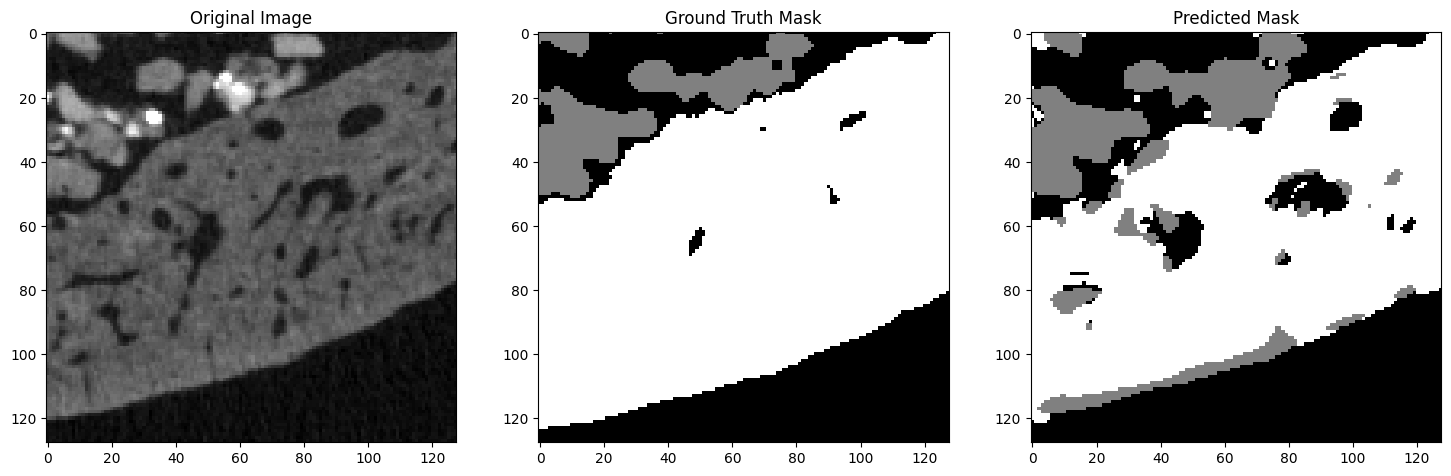

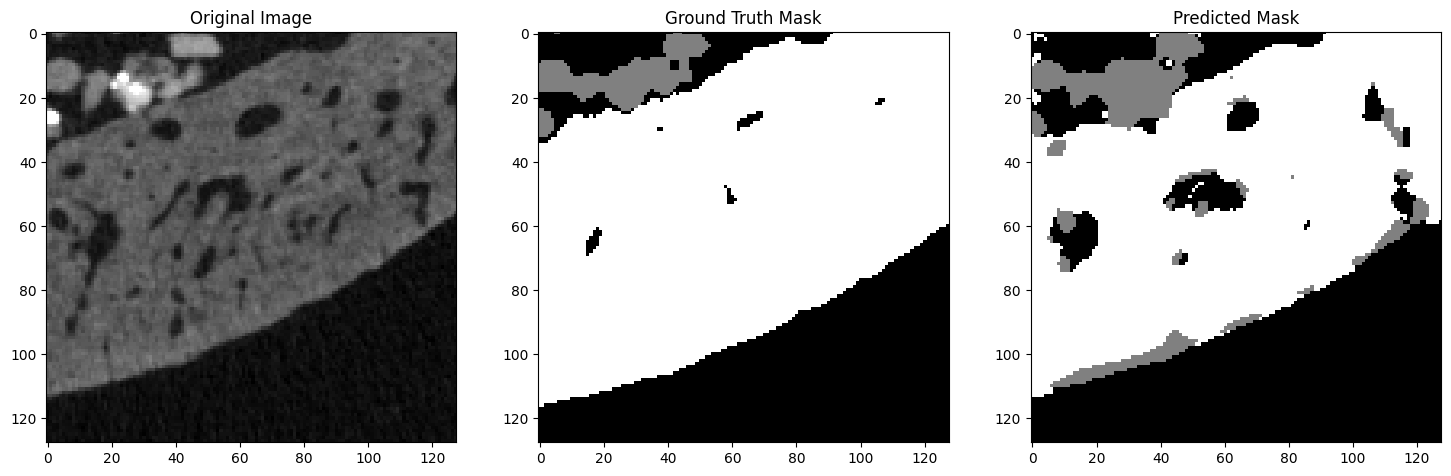

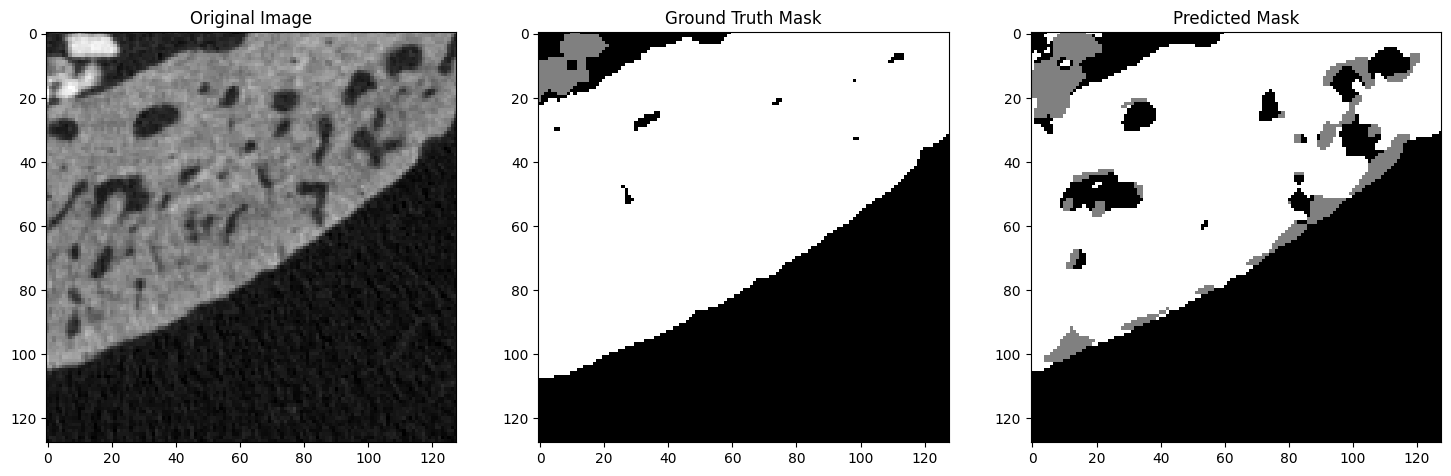

In [26]:
def visualize_last_batch(dataloader, model, device):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            image = sample['image'].to(device)
            mask = sample['mask'].to(device)

            # Store the last batch
            last_image_batch = image
            last_mask_batch = mask

        # Make predictions on the last batch
        output = model(last_image_batch)
        preds = output.argmax(dim=1)

        # Move predictions to CPU and convert to numpy array
        preds = preds.cpu().numpy()
        masks = last_mask_batch.cpu().numpy()

        # Inspect unique values in the predictions and masks
        unique_values_preds = np.unique(preds)
        unique_values_masks = np.unique(masks)
        print(f"Unique values in predictions: {unique_values_preds}")
        print(f"Unique values in ground truth masks: {unique_values_masks}")

        # Debugging: Check the shape of inputs and outputs
        print(f"Input batch shape: {last_image_batch.shape}")
        print(f"Mask batch shape: {last_mask_batch.shape}")
        print(f"Prediction batch shape: {preds.shape}")

        # Ensure the output dimensions match the input dimensions
        assert preds.shape[1:] == last_image_batch.shape[2:], (
            f"Output shape {preds.shape[1:]} does not match input shape {last_image_batch.shape[2:]}"
        )

        # Visualize the last batch
        batch_size = preds.shape[0]
        for idx in range(batch_size):
            plt.figure(figsize=(18, 6))

            # Original Image (Middle slice for 2.5D)
            plt.subplot(1, 3, 1)
            plt.title("Original Image")
            image_np = last_image_batch[idx].cpu().numpy()
            if image_np.ndim == 3:
                if image_np.shape[0] == 3:  # 2.5D image with 3 channels
                    middle_slice = image_np[1]  # Selecting the middle slice
                    plt.imshow(middle_slice, cmap='gray')
                elif image_np.shape[0] == 1:  # Single channel but 3D (like [1, H, W])
                    plt.imshow(image_np[0], cmap='gray')
                elif image_np.shape[0] % 2 == 1:  # Multichannel image with odd number of channels
                    middle_slice = image_np[image_np.shape[0] // 2]  # Selecting the middle slice
                    plt.imshow(middle_slice, cmap='gray')
                else:  # Multichannel image with even number of channels
                    middle_slice = image_np[image_np.shape[0] // 2 - 1]  # Selecting a representative slice
                    plt.imshow(middle_slice, cmap='gray')
            else:
                plt.imshow(image_np, cmap='gray')

            # Ground Truth Mask
            plt.subplot(1, 3, 2)
            plt.title("Ground Truth Mask")
            plt.imshow(masks[idx], cmap='gray')

            # Predicted Mask
            plt.subplot(1, 3, 3)
            plt.title("Predicted Mask")
            plt.imshow(preds[idx], cmap='gray')

            plt.show()

# Example usage with your validation DataLoader
visualize_last_batch(val_data_loader, net, device)
